#Welcome to our project

#Import libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error, r2_score, mean_absolute_error, confusion_matrix
from sklearn.preprocessing import MinMaxScaler
from imblearn.over_sampling import RandomOverSampler
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#Import dataset

In [ ]:
all_files = [
    "/content/drive/MyDrive/MachineLearningCVE/Wednesday-workingHours.pcap_ISCX.csv",
    "/content/drive/MyDrive/MachineLearningCVE/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv",
    "/content/drive/MyDrive/MachineLearningCVE/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv",
    "/content/drive/MyDrive/MachineLearningCVE/Friday-WorkingHours-Morning.pcap_ISCX.csv",
    "/content/drive/MyDrive/MachineLearningCVE/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv",
    "/content/drive/MyDrive/MachineLearningCVE/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv",
    "/content/drive/MyDrive/MachineLearningCVE/Tuesday-WorkingHours.pcap_ISCX.csv"
]
def load_and_clean(file_path):
    df_0 = pd.read_csv(file_path, low_memory=False)
    df_0.columns = df_0.columns.str.strip()
    df_0 = df_0.drop('Destination Port',axis= 1)
    print(df_0.shape)
    df_0 = df_0.replace([np.inf, -np.inf], np.nan).dropna(axis=1)
    return df_0

df_0 = pd.concat([load_and_clean(f) for f in all_files], ignore_index=True)

# Preserve original labels in a new column 'OriginalLabel'
df_0.rename(columns={'Label': 'OriginalLabel'}, inplace=True)
# Create binary label: 0 for benign, 1 for malicious
df_0['Label'] = df_0['OriginalLabel'].apply(lambda x: 0 if str(x).upper() == 'BENIGN' else 1)


(692703, 78)
(225745, 78)
(286467, 78)
(191033, 78)
(288602, 78)
(170366, 78)
(445909, 78)


In [ ]:
df_0

,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,OriginalLabel,Label
0,38308,1,1,6,6,6,6,6.000000,0.000000,6,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,0
1,479,11,5,172,326,79,0,15.636364,31.449238,163,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,0
2,1095,10,6,3150,3150,1575,0,315.000000,632.561635,1575,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,0
3,15206,17,12,3452,6660,1313,0,203.058823,425.778474,3069,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,0
4,1092,9,6,3150,3152,1575,0,350.000000,694.509719,1576,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2300820,155,2,2,88,120,44,44,44.000000,0.000000,60,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,0
2300821,110,1,1,0,0,0,0,0.000000,0.000000,0,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,0
2300822,166,2,2,88,188,44,44,44.000000,0.000000,94,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,0
2300823,81,1,1,0,0,0,0,0.000000,0.000000,0,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,0


In [ ]:
#for label in df_0.columns:
  #plt.hist(df_0[df_0['Label']== 0][label], color = 'blue', label = 'benign', alpha = 0.7, density=True)
  #plt.hist(df_0[df_0['Label']== 1][label], color = 'red', label = 'malicious', alpha = 0.7, density=True)
  #plt.title(label)
  #plt.ylabel("Probability")
  #plt.xlabel(label)
  #plt.legend()
  #plt.show()

#Data split

In [ ]:
from sklearn.model_selection import StratifiedKFold
import numpy as np
import pandas as pd

def stratified_split_into_n_chunks(df, n_chunks=5, label_col='Label', random_state=42):

# Prepare output lists
  chunks = [ [] for _ in range(n_chunks) ]

# StratifiedKFold splits data into n_chunks directly
  skf = StratifiedKFold(
    n_splits=n_chunks,
    shuffle=True,
    random_state=random_state
  )

  # Assign indices to chunks
  for chunk_id, (_, test_idx) in enumerate(
      skf.split(df, df[label_col])
  ):
    chunks[chunk_id] = df.iloc[test_idx].sample(frac=1, random_state=random_state).reset_index(drop=True)

# Print summary
  print(f"Split into {len(chunks)} chunks:")
  for i, chunk in enumerate(chunks):
    print(f" Chunk {i}: {len(chunk):,} samples -> "
          f"{chunk[label_col].value_counts(normalize=True).to_dict()}")

  return chunks

In [ ]:
chunks = stratified_split_into_n_chunks(
    df_0, n_chunks=5, label_col='OriginalLabel', random_state=42
    )

# Now use as you planned:
df = chunks[0]                    # use this for train/val/test splits
test_2, test_3, test_4, test_5  = chunks[1:]                   # truly held-out for final evaluation

Split into 5 chunks:
 Chunk 0: 460,165 samples -> {'BENIGN': 0.7576325883107147, 'DoS Hulk': 0.10043136700965957, 'PortScan': 0.06907522301783056, 'DDoS': 0.05564308454576076, 'DoS GoldenEye': 0.004472308845740115, 'FTP-Patator': 0.003450936077276629, 'SSH-Patator': 0.002562124455358404, 'DoS slowloris': 0.002518661784359958, 'DoS Slowhttptest': 0.0023904469049145414, 'Bot': 0.000854041485119468, 'Web Attack � Brute Force': 0.0006562863320765378, 'Web Attack � XSS': 0.0002825073614899004, 'Infiltration': 1.5211934849456174e-05, 'Web Attack � Sql Injection': 8.692534199689242e-06, 'Heartbleed': 6.5194006497669315e-06}
 Chunk 1: 460,165 samples -> {'BENIGN': 0.7576325883107147, 'DoS Hulk': 0.10043136700965957, 'PortScan': 0.06907522301783056, 'DDoS': 0.05564525767931068, 'DoS GoldenEye': 0.004472308845740115, 'FTP-Patator': 0.003450936077276629, 'SSH-Patator': 0.002562124455358404, 'DoS slowloris': 0.002518661784359958, 'DoS Slowhttptest': 0.0023904469049145414, 'Bot': 0.0008540414851194

In [ ]:
df

,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,OriginalLabel,Label
0,5083284,9,6,345,6079,188,0,38.333333,69.781803,2920,...,0.000,0.000,0,0,0.0,0.0,0,0,BENIGN,0
1,44,1,1,2,6,2,2,2.000000,0.000000,6,...,0.000,0.000,0,0,0.0,0.0,0,0,PortScan,1
2,1,3,0,31,0,31,0,10.333333,17.897858,0,...,0.000,0.000,0,0,0.0,0.0,0,0,BENIGN,0
3,194,2,2,142,398,71,71,71.000000,0.000000,199,...,0.000,0.000,0,0,0.0,0.0,0,0,BENIGN,0
4,157,2,2,78,180,39,39,39.000000,0.000000,90,...,0.000,0.000,0,0,0.0,0.0,0,0,BENIGN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
460160,119974666,160,252,124073,108038,5868,0,775.456250,1642.407019,2235,...,2193782.333,1939048.972,4105544,228552,37400000.0,27600000.0,58700000,6145152,BENIGN,0
460161,211,2,2,84,212,42,42,42.000000,0.000000,106,...,0.000,0.000,0,0,0.0,0.0,0,0,BENIGN,0
460162,49,1,2,0,0,0,0,0.000000,0.000000,0,...,0.000,0.000,0,0,0.0,0.0,0,0,BENIGN,0
460163,3344933,5,0,30,0,6,6,6.000000,0.000000,0,...,0.000,0.000,0,0,0.0,0.0,0,0,DDoS,1


In [ ]:
test_2

,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,62450263,7,2,169,92,46,0,24.142857,23.197906,46,...,32,36341.0,0.0,36341,36341,58400000.0,0.0,58400000,58400000,0
1,12,1,1,2,6,2,2,2.000000,0.000000,6,...,24,0.0,0.0,0,0,0.0,0.0,0,0,1
2,40507346,45,53,2405,64000,1029,0,53.444444,203.947136,1740,...,32,628421.0,0.0,628421,628421,39900000.0,0.0,39900000,39900000,0
3,42095,2,1,44,6,38,6,22.000000,22.627417,6,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0
4,48197,1,1,47,103,47,47,47.000000,0.000000,103,...,32,0.0,0.0,0,0,0.0,0.0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
460160,98,2,0,12,0,6,6,6.000000,0.000000,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0
460161,21,1,1,0,0,0,0,0.000000,0.000000,0,...,32,0.0,0.0,0,0,0.0,0.0,0,0,0
460162,24269,2,2,72,460,36,36,36.000000,0.000000,230,...,32,0.0,0.0,0,0,0.0,0.0,0,0,0
460163,71535213,7,10,11607,68,5840,0,1658.142857,2127.597740,20,...,20,30154.0,0.0,30154,30154,35400000.0,34000000.0,59500000,11400000,0


In [ ]:
test_3

,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,61247,2,2,66,500,33,33,33.000,0.000000,250,...,32,0.0,0.0,0,0,0.0,0.0,0,0,0
1,9,1,1,2,6,2,2,2.000,0.000000,6,...,24,0.0,0.0,0,0,0.0,0.0,0,0,1
2,5551343,8,6,383,3222,202,0,47.875,75.070324,1460,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0
3,60410,1,1,64,117,64,64,64.000,0.000000,117,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0
4,893,2,0,0,0,0,0,0.000,0.000000,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
460160,11134107,10,10,1377,6713,1022,0,137.700,317.667209,1689,...,20,1133951.0,0.0,1133951,1133951,10000000.0,0.0,10000000,10000000,0
460161,33,1,1,6,6,6,6,6.000,0.000000,6,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0
460162,220,2,2,74,262,37,37,37.000,0.000000,131,...,32,0.0,0.0,0,0,0.0,0.0,0,0,0
460163,73107451,8,5,56,11601,20,0,7.000,5.656854,4380,...,20,4026.0,0.0,4026,4026,36500000.0,42800000.0,66800000,6259875,1


##Function to scale dataset

In [ ]:
def scale_dataset(dataframe, oversample=False, scaler=None, fit_scaler=True):
    df_copy = dataframe.copy()

    if 'OriginalLabel' in df_copy.columns:
        df_copy = df_copy.drop('OriginalLabel', axis=1)

    X = df_copy[df_copy.columns[:-1]].values
    y = df_copy[df_copy.columns[-1]].values

    if scaler is None:
        scaler = MinMaxScaler()
        X = scaler.fit_transform(X)
    elif fit_scaler:
        X = scaler.fit_transform(X)
    else:
        X = scaler.transform(X)

    if oversample:
        ros = RandomOverSampler()
        X, y = ros.fit_resample(X, y)

    data = np.hstack((X, np.reshape(y, (-1, 1))))

    return data, X, y, scaler

##Choose split amount

In [ ]:
def split(split_amount):
  df_shuffled = df.sample(frac=1, random_state=42)
  train_current_df, test_current_df = np.split(df_shuffled, [int(split_amount*len(df_shuffled))])

  # First scale and oversample train_current_df, and get the fitted scaler
  train_current, X_train_current, y_train_current, data_scaler = scale_dataset(train_current_df, oversample=True, fit_scaler=True)

  # Then scale test_current_df using the SAME fitted scaler, without oversampling
  test_current, X_test_current, y_test_current, _ = scale_dataset(test_current_df, oversample=False, scaler=data_scaler, fit_scaler=False)

  return train_current, test_current, X_train_current, y_train_current, X_test_current, y_test_current, data_scaler


In [ ]:
split_amount= float(input("Choose your train data split (0.5 for 50% 50%, 0.7 for 70% 30%, 0.8 for 80% 20%):"))
if split_amount == 0.5:
  train_current,test_current,X_train_current, y_train_current,X_test_current, y_test_current, data_scaler = split(split_amount)
  current_split_name = '50/50 split'
elif split_amount == 0.7:
    train_current,test_current,X_train_current, y_train_current,X_test_current, y_test_current, data_scaler = split(split_amount)
    current_split_name = '70/30 split'
elif split_amount == 0.8:
    train_current,test_current,X_train_current, y_train_current,X_test_current, y_test_current, data_scaler = split(split_amount)
    current_split_name = '80/20 split'
else:
  print("Invalid input, try again")

Choose your train data split (0.5 for 50% 50%, 0.7 for 70% 30%, 0.8 for 80% 20%):0.5


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [ ]:
print(sum(y_train_current==0))
print(sum(y_train_current==1))

243993
243993


In [ ]:
df

,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,175,2,2,82,210,41,41,41.00,0.000000,105,...,32,0.0000,0.0000,0,0,0.000,0.00000,0,0,0
1,50,1,1,2,6,2,2,2.00,0.000000,6,...,24,0.0000,0.0000,0,0,0.000,0.00000,0,0,1
2,30650,1,1,42,58,42,42,42.00,0.000000,58,...,32,0.0000,0.0000,0,0,0.000,0.00000,0,0,0
3,194,2,2,142,398,71,71,71.00,0.000000,199,...,32,0.0000,0.0000,0,0,0.000,0.00000,0,0,0
4,2992827,8,4,310,290,228,0,38.75,78.861089,145,...,20,0.0000,0.0000,0,0,0.000,0.00000,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
460160,65227245,10,10,404,300,356,0,40.40,110.906567,288,...,20,169963.6667,139430.6163,454554,111708,9959468.333,92612.58252,9999801,9770499,0
460161,60,2,1,31,6,31,0,15.50,21.920310,6,...,32,0.0000,0.0000,0,0,0.000,0.00000,0,0,0
460162,150,2,2,54,54,27,27,27.00,0.000000,27,...,32,0.0000,0.0000,0,0,0.000,0.00000,0,0,0
460163,5941801,5,0,30,0,6,6,6.00,0.000000,0,...,20,1743.0000,0.0000,1743,1743,5940058.000,0.00000,5940058,5940058,1


In [ ]:
test_2

,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,62450263,7,2,169,92,46,0,24.142857,23.197906,46,...,32,36341.0,0.0,36341,36341,58400000.0,0.0,58400000,58400000,0
1,12,1,1,2,6,2,2,2.000000,0.000000,6,...,24,0.0,0.0,0,0,0.0,0.0,0,0,1
2,40507346,45,53,2405,64000,1029,0,53.444444,203.947136,1740,...,32,628421.0,0.0,628421,628421,39900000.0,0.0,39900000,39900000,0
3,42095,2,1,44,6,38,6,22.000000,22.627417,6,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0
4,48197,1,1,47,103,47,47,47.000000,0.000000,103,...,32,0.0,0.0,0,0,0.0,0.0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
460160,98,2,0,12,0,6,6,6.000000,0.000000,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0
460161,21,1,1,0,0,0,0,0.000000,0.000000,0,...,32,0.0,0.0,0,0,0.0,0.0,0,0,0
460162,24269,2,2,72,460,36,36,36.000000,0.000000,230,...,32,0.0,0.0,0,0,0.0,0.0,0,0,0
460163,71535213,7,10,11607,68,5840,0,1658.142857,2127.597740,20,...,20,30154.0,0.0,30154,30154,35400000.0,34000000.0,59500000,11400000,0


In [ ]:
test_3

,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,61247,2,2,66,500,33,33,33.000,0.000000,250,...,32,0.0,0.0,0,0,0.0,0.0,0,0,0
1,9,1,1,2,6,2,2,2.000,0.000000,6,...,24,0.0,0.0,0,0,0.0,0.0,0,0,1
2,5551343,8,6,383,3222,202,0,47.875,75.070324,1460,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0
3,60410,1,1,64,117,64,64,64.000,0.000000,117,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0
4,893,2,0,0,0,0,0,0.000,0.000000,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
460160,11134107,10,10,1377,6713,1022,0,137.700,317.667209,1689,...,20,1133951.0,0.0,1133951,1133951,10000000.0,0.0,10000000,10000000,0
460161,33,1,1,6,6,6,6,6.000,0.000000,6,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0
460162,220,2,2,74,262,37,37,37.000,0.000000,131,...,32,0.0,0.0,0,0,0.0,0.0,0,0,0
460163,73107451,8,5,56,11601,20,0,7.000,5.656854,4380,...,20,4026.0,0.0,4026,4026,36500000.0,42800000.0,66800000,6259875,1


In [ ]:
X_train_current

array([[5.16666934e-07, 0.00000000e+00, 3.62224347e-06, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [5.33413609e-02, 0.00000000e+00, 2.17334608e-05, ...,
        0.00000000e+00, 5.30609250e-02, 5.30609250e-02],
       [4.16666882e-07, 4.84390516e-06, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       ...,
       [1.99483436e-04, 9.68781031e-06, 1.44889739e-05, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [9.87409927e-02, 9.68781031e-05, 1.15911791e-04, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [3.90833535e-06, 1.45317155e-05, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00]])

In [ ]:
# List of the raw test sets
test_sets_raw = [test_2, test_3, test_4, test_5]

# Lists to store the scaled versions
X_test_scaled = []
y_test_scaled = []

# Loop through each test set and scale it
for i, test_set in enumerate(test_sets_raw, start=2):
    print(f"Scaling test_{i}...")
    _, X_test_i, y_test_i = scale_dataset(test_set, oversample=False)

    # Store in dynamically named variables
    globals()[f"X_test_{i}"] = X_test_i
    globals()[f"y_test_{i}"] = y_test_i

    # Also collect them in lists
    X_test_scaled.append(X_test_i)
    y_test_scaled.append(y_test_i)

# Now you have all of these variables automatically created:
# X_test_2, y_test_2
# X_test_3, y_test_3
# X_test_4, y_test_4
# X_test_5, y_test_5
X_test_2,X_test_3,X_test_4,X_test_5 = X_test_scaled
y_test_2,y_test_3,y_test_4,y_test_5 = y_test_scaled

Scaling test_2...
Scaling test_3...
Scaling test_4...
Scaling test_5...


In [ ]:
X_test_2

array([[5.20419001e-01, 3.00655429e-05, 7.41787485e-06, ...,
        0.00000000e+00, 4.86666667e-01, 4.86666667e-01],
       [2.08333347e-07, 0.00000000e+00, 3.70893743e-06, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [3.37561348e-01, 2.20480648e-04, 1.96573684e-04, ...,
        0.00000000e+00, 3.32500000e-01, 3.32500000e-01],
       ...,
       [2.02350013e-04, 5.01092381e-06, 7.41787485e-06, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [5.96126923e-01, 3.00655429e-05, 3.70893743e-05, ...,
        4.42132640e-01, 4.95833333e-01, 9.50000000e-02],
       [1.87904796e-01, 1.50327714e-05, 1.48357497e-05, ...,
        0.00000000e+00, 1.87500000e-01, 1.87500000e-01]])

In [ ]:
X_test_3

array([[5.10400004e-04, 1.15400150e-05, 1.72654915e-05, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [8.33333340e-08, 0.00000000e+00, 8.63274573e-06, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [4.62612004e-02, 8.07801050e-05, 5.17964744e-05, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       ...,
       [1.84166668e-06, 1.15400150e-05, 1.72654915e-05, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [6.09228772e-01, 8.07801050e-05, 4.31637287e-05, ...,
        5.79945799e-01, 5.56666667e-01, 5.21656250e-02],
       [1.00634168e-03, 3.46200450e-05, 1.72654915e-05, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00]])

In [ ]:
y_test_2

array([0, 1, 0, ..., 0, 0, 0])

In [ ]:
X_test_scaled

[array([[5.20419001e-01, 3.00655429e-05, 7.41787485e-06, ...,
         0.00000000e+00, 4.86666667e-01, 4.86666667e-01],
        [2.08333347e-07, 0.00000000e+00, 3.70893743e-06, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [3.37561348e-01, 2.20480648e-04, 1.96573684e-04, ...,
         0.00000000e+00, 3.32500000e-01, 3.32500000e-01],
        ...,
        [2.02350013e-04, 5.01092381e-06, 7.41787485e-06, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [5.96126923e-01, 3.00655429e-05, 3.70893743e-05, ...,
         4.42132640e-01, 4.95833333e-01, 9.50000000e-02],
        [1.87904796e-01, 1.50327714e-05, 1.48357497e-05, ...,
         0.00000000e+00, 1.87500000e-01, 1.87500000e-01]]),
 array([[5.10400004e-04, 1.15400150e-05, 1.72654915e-05, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [8.33333340e-08, 0.00000000e+00, 8.63274573e-06, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [4.62612004e-02, 

##Save results after training

In [ ]:
import gspread
from datetime import datetime
import pandas as pd
from sklearn.metrics import classification_report, accuracy_score

# ONE-TIME SETUP (run once, then never touch again)
gc = gspread.service_account(filename='/content/drive/MyDrive/elated-coral-479502-s6-7a57315a7ed6.json')  # your JSON file
sh = gc.open("Train_results")                      # your Google Sheet name
ws = sh.worksheet("All results")                               # tab name

# THE ONLY FUNCTION YOU WILL EVER CALL
def save_result(
    split,              # e.g., "70/30", "80/20"
    model, # whatever you used
    vectorizer,        # or "Count", "Hashing", etc.
    accuracy=None,
    f1_weighted=None,
    recall_weighted=None,
    precision_weighted=None,
    f1_macro=None,
    recall_macro=None,
    precision_macro=None,
    f1_class_0=None,
    recall_class_0=None,
    precision_class_0=None,
    f1_class_1=None,
    recall_class_1=None,
    precision_class_1=None,
    notes="",
    extra_params=None           # optional dict, e.g., {"C": 1, "lr": 2e-5}
):
    """
    Call this ONCE at the end of each training run.
    Example:
        save_result(split="70/30", model="XGBoost", f1_weighted=0.928, notes="best so far!")
    """
    row = {
        "timestamp":        datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "split":            split,
        "model":            model,
        "vectorizer":       vectorizer or "",
        "accuracy":         round(accuracy, 4) if accuracy else "",
        "f1_weighted":      round(f1_weighted, 4) if f1_weighted else "",
        "recall_weighted":  round(recall_weighted, 4) if recall_weighted else "",
        "precision_weighted":round(precision_weighted, 4) if precision_weighted else "",
        "f1_macro":         round(f1_macro, 4) if f1_macro else "",
        "recall_macro":     round(recall_macro, 4) if recall_macro else "",
        "precision_macro":  round(precision_macro, 4) if precision_macro else "",
        "f1_class_0":       round(f1_class_0, 4) if f1_class_0 else "",
        "recall_class_0":   round(recall_class_0, 4) if recall_class_0 else "",
        "precision_class_0":round(precision_class_0, 4) if precision_class_0 else "",
        "f1_class_1":       round(f1_class_1, 4) if f1_class_1 else "",
        "recall_class_1":   round(recall_class_1, 4) if recall_class_1 else "",
        "precision_class_1":round(precision_class_1, 4) if precision_class_1 else "",
        "notes":            notes,
        "params":           str(extra_params) if extra_params else "",
    }

    # Append the row to Google Sheets
    ws.append_row(list(row.values()), value_input_option='USER_ENTERED')
    print(f"SAVED \u2192 {split} | {model} | f1_weighted={f1_weighted} | {notes}")


def evaluate_and_save_metrics(
    split_name, model_name, vectorizer_name, y_true, y_pred, notes="", extra_params=None
):
    """
    Evaluates model predictions and saves all relevant metrics using the save_result function.
    """
    report = classification_report(y_true, y_pred, output_dict=True)

    save_result(
        split=split_name,
        model=model_name,
        vectorizer=vectorizer_name,
        accuracy=report["accuracy"],
        f1_weighted=report["weighted avg"]["f1-score"],
        recall_weighted=report["weighted avg"]["recall"],
        precision_weighted=report["weighted avg"]["precision"],
        f1_macro=report["macro avg"]["f1-score"],
        recall_macro=report["macro avg"]["recall"],
        precision_macro=report["macro avg"]["precision"],
        f1_class_0=report["0"]["f1-score"],
        recall_class_0=report["0"]["recall"],
        precision_class_0=report["0"]["precision"],
        f1_class_1=report["1"]["f1-score"],
        recall_class_1=report["1"]["recall"],
        precision_class_1=report["1"]["precision"],
        notes=notes,
        extra_params=extra_params,
    )


#Supervised learning algorithms

In [1]:
# FULL 5 SUPERVISED ALGORITHMS — EXACTLY LIKE YOUR LOGISTIC REGRESSION EXAMPLE
# GridSearchCV + Best Params + Classification Report + Confusion Matrix
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV, train_test_split
import warnings
warnings.filterwarnings('ignore')

print(f"Dataset → Train: {X_train_current.shape} | Test: {X_test_current.shape} | Attack in test: {y_test_current.mean():.3%}\n")
print("="*100)

NameError: name 'X_train_current' is not defined

##1. Logistic regression

Fitting 3 folds for each of 8 candidates, totalling 24 fits
LR Best params: {'logisticregression__C': np.float64(10.0), 'logisticregression__l1_ratio': 0.5}
Accuracy: 0.8663
ROC-AUC: 0.9648
              precision    recall  f1-score   support

           0       0.85      1.00      0.92     69805
           1       0.98      0.45      0.62     22228

    accuracy                           0.87     92033
   macro avg       0.92      0.73      0.77     92033
weighted avg       0.88      0.87      0.85     92033



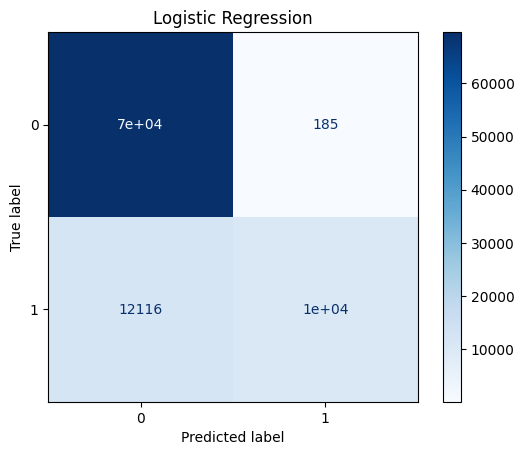

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

print("1. LOGISTIC REGRESSION — GridSearchCV Tuning")
X_tune, _, y_tune, _ = train_test_split(X_train_current, y_train_current, train_size=0.2, stratify=y_train_current, random_state=42)

pipe = make_pipeline(LogisticRegression(solver='saga', penalty='elasticnet', class_weight='balanced', max_iter=1000, n_jobs=-1))
param_grid = {
    'logisticregression__C': np.logspace(-2, 2, 5),
    'logisticregression__l1_ratio': [0.0, 0.15, 0.5, 0.85, 1.0]
}
grid = GridSearchCV(pipe, param_grid, cv=3, scoring='f1', n_jobs=-1, verbose=1)
grid.fit(X_tune, y_tune)

best_model = grid.best_estimator_
best_model.fit(X_train_current, y_train_current)

y_pred = best_model.predict(X_test_current)
y_proba = best_model.predict_proba(X_test_current)[:,1]

print("LR Best params:", grid.best_params_)
print(f"Accuracy: {accuracy_score(y_test_current, y_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test_current, y_proba):.4f}")
print(classification_report(y_test_current, y_pred, digits=4))

cm = confusion_matrix(y_test_current, y_pred)
ConfusionMatrixDisplay(cm).plot(cmap='Blues')
plt.title("Logistic Regression", fontweight='bold')
plt.show()
print("-"*90)

In [ ]:

evaluate_and_save_metrics(
    split_name=current_split_name,
    model_name="Logistic regression",
    vectorizer_name="TF-IDF",
    y_true=y_test_current,
    y_pred=y_pred,
    notes="test_1"
)

SAVED → 80/20 split | Logistic regression | f1_weighted=0.847088280269636 | test_1


In [ ]:
y_pred = clf.predict(X_test_2)
y_pred_proba = clf.predict_proba(X_test_2)[:, 1]  # probability of positive class
report = classification_report(y_test_2, y_pred, output_dict=True)

In [ ]:

evaluate_and_save_metrics(
    split_name=current_split_name,
    model_name="Logistic regression",
    vectorizer_name="TF-IDF",
    y_true=y_test_2,
    y_pred=y_pred,
    notes="test_2"
)

SAVED → 80/20 split | Logistic regression | f1_weighted=0.8890904229030008 | test_2


In [ ]:
y_pred = clf.predict(X_test_3)
y_pred_proba = clf.predict_proba(X_test_3)[:, 1]  # probability of positive class
report = classification_report(y_test_3, y_pred, output_dict=True)

In [ ]:

evaluate_and_save_metrics(
    split_name=current_split_name,
    model_name="Logistic regression",
    vectorizer_name="TF-IDF",
    y_true=y_test_3,
    y_pred=y_pred,
    notes="test_3"
)

SAVED → 80/20 split | Logistic regression | f1_weighted=0.8399575636704637 | test_3


In [ ]:
y_pred = clf.predict(X_test_4)
y_pred_proba = clf.predict_proba(X_test_4)[:, 1]  # probability of positive class
report = classification_report(y_test_4, y_pred, output_dict=True)

In [ ]:

evaluate_and_save_metrics(
    split_name=current_split_name,
    model_name="Logistic regression",
    vectorizer_name="TF-IDF",
    y_true=y_test_4,
    y_pred=y_pred,
    notes="test_4"
)

SAVED → 80/20 split | Logistic regression | f1_weighted=0.8880504802592248 | test_4


In [ ]:
y_pred = clf.predict(X_test_5)
y_pred_proba = clf.predict_proba(X_test_5)[:, 1]  # probability of positive class
report = classification_report(y_test_5, y_pred, output_dict=True)

In [ ]:

evaluate_and_save_metrics(
    split_name=current_split_name,
    model_name="Logistic regression",
    vectorizer_name="TF-IDF",
    y_true=y_test_5,
    y_pred=y_pred,
    notes="test_5"
)

SAVED → 80/20 split | Logistic regression | f1_weighted=0.8354248850174418 | test_5


##2. Support Vector Machine (SVM)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
SVM Best params: {'sgdclassifier__alpha': np.float64(0.0001), 'sgdclassifier__l1_ratio': 0.5}
Accuracy: 0.8655
ROC-AUC: 0.9606
              precision    recall  f1-score   support

           0       0.98      0.84      0.90     69805
           1       0.65      0.95      0.77     22228

    accuracy                           0.87     92033
   macro avg       0.82      0.89      0.84     92033
weighted avg       0.90      0.87      0.87     92033



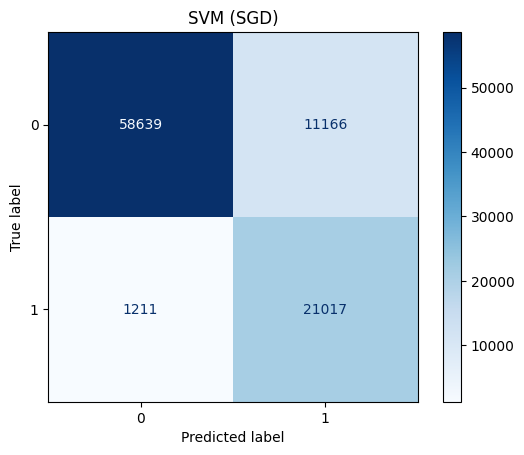

In [ ]:
# -------------------------------------------------------------
# 2. Linear SVM (SGDClassifier) — ~5–15 min total
# -------------------------------------------------------------
from sklearn.linear_model import SGDClassifier

X_tune, _, y_tune, _ = train_test_split(
    X_train_current, y_train_current,
    train_size=0.2, stratify=y_train_current, random_state=42
)

svm_pipeline = make_pipeline(
    SGDClassifier(
        loss='modified_huber',          # gives predict_proba
        penalty='elasticnet',
        class_weight='balanced',
        max_iter=1000, tol=1e-3,
        learning_rate='optimal',
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=5,
        random_state=42, n_jobs=-1
    )
)

param_grid = {
    'sgdclassifier__alpha': np.logspace(-4, -1, 4),
    'sgdclassifier__l1_ratio': [0.0, 0.15, 0.5]
}

svm = GridSearchCV(svm_pipeline, param_grid, cv=3, scoring='f1', n_jobs=-1, verbose=1)
svm.fit(X_tune, y_tune)

best_svm = svm.best_estimator_
best_svm.fit(X_train_current, y_train_current)

print("SVM Best params:", svm.best_params_)
y_pred = best_svm.predict(X_test_current)
y_pred_proba = best_svm.predict_proba(X_test_current)[:, 1]

print(f"Accuracy: {accuracy_score(y_test_current, y_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test_current, y_pred_proba):.4f}")
print(classification_report(y_test_current, y_pred))
report=classification_report(y_test_current, y_pred,output_dict=True)

cm = confusion_matrix(y_test_current, y_pred)
ConfusionMatrixDisplay(cm).plot(cmap='Blues')
plt.title("SVM (SGD)")
plt.show()

In [ ]:

evaluate_and_save_metrics(
    split_name=current_split_name,
    model_name="SVM",
    vectorizer_name="TF-IDF",
    y_true=y_test_current,
    y_pred=y_pred,
    notes="test_1"
)

SAVED → 80/20 split | SVM | f1_weighted=0.8726553140614327 | test_1


In [ ]:
y_pred = svm.predict(X_test_2)
report = classification_report(y_test_2, y_pred, output_dict=True)

In [ ]:

evaluate_and_save_metrics(
    split_name=current_split_name,
    model_name="SVM",
    vectorizer_name="TF-IDF",
    y_true=y_test_2,
    y_pred=y_pred,
    notes="test_2"
)

SAVED → 80/20 split | SVM | f1_weighted=0.8723237464669888 | test_2


In [ ]:
y_pred = svm.predict(X_test_3)
report = classification_report(y_test_3, y_pred, output_dict=True)

In [ ]:

evaluate_and_save_metrics(
    split_name=current_split_name,
    model_name="SVM",
    vectorizer_name="TF-IDF",
    y_true=y_test_3,
    y_pred=y_pred,
    notes="test_3"
)

SAVED → 80/20 split | SVM | f1_weighted=0.8740922632191656 | test_3


In [ ]:
y_pred = svm.predict(X_test_4)
report = classification_report(y_test_4, y_pred, output_dict=True)

In [ ]:

evaluate_and_save_metrics(
    split_name=current_split_name,
    model_name="SVM",
    vectorizer_name="TF-IDF",
    y_true=y_test_4,
    y_pred=y_pred,
    notes="test_4"
)

SAVED → 80/20 split | SVM | f1_weighted=0.8735428185242236 | test_4


In [ ]:
y_pred = svm.predict(X_test_5)
report = classification_report(y_test_5, y_pred, output_dict=True)

In [ ]:

evaluate_and_save_metrics(
    split_name=current_split_name,
    model_name="SVM",
    vectorizer_name="TF-IDF",
    y_true=y_test_5,
    y_pred=y_pred,
    notes="test_5"
)

SAVED → 80/20 split | SVM | f1_weighted=0.8652617231070443 | test_5


##3. Artificial neural network (ANN)

In [ ]:
!pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 5.7 MB/s eta 0:00:00


Trial 8 Complete [00h 02m 27s]
val_auc: 0.0

Best val_auc So Far: 0.0
Total elapsed time: 00h 21m 41s


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Epoch 1/80
1743/1743 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - accuracy: 0.9224 - auc: 0.9786 - loss: 0.1802 - val_accuracy: 0.9318 - val_auc: 0.0000e+00 - val_loss: 0.1595 - learning_rate: 1.0899e-04
Epoch 2/80
1743/1743 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - accuracy: 0.9348 - auc: 0.9831 - loss: 0.1602 - val_accuracy: 0.9329 - val_auc: 0.0000e+00 - val_loss: 0.1530 - learning_rate: 1.0899e-04
Epoch 3/80
1743/1743 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9388 - auc: 0.9852 - loss: 0.1500 - val_accuracy: 0.9326 - val_auc: 0.0000e+00 - val_loss: 0.1446 - learning_rate: 1.0899e-04
Epoch 4/80
1743/1743 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9411 - auc: 0.9862 - loss: 0.1444 - val_accuracy: 0.9340 - val_auc: 0.0000e+00 - val_loss: 0.1607 - learning_rate: 1.0899e-04
Epoch 5/80
1743/1743 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9437 - auc: 0.9872 - loss: 0.1381 - val_accuracy: 0.9373 - val_auc: 0.0000e+00 - val_loss: 0.1355 - learning_rate: 1.0899e-04
Epoch 6/80
1743/1743 ━━━━━━━

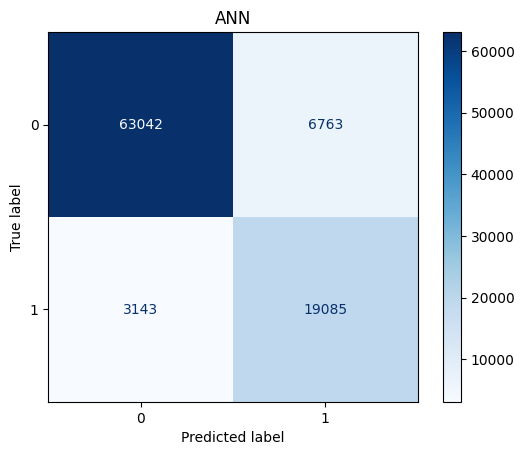

In [ ]:
# -------------------------------------------------------------
# 3. Neural Network (Keras) — ~20–60 min CPU | <10 min GPU
# -------------------------------------------------------------

import kerastuner as kt
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.utils.class_weight import compute_class_weight

# Strongly recommended: switch to GPU runtime first!
# Runtime → Change runtime type → Hardware accelerator = GPU

# Optional fast PCA (30 components) — cuts time 40–60%
from sklearn.decomposition import PCA
pca = PCA(n_components=30, random_state=42)
X_train_pca = pca.fit_transform(X_train_current)
X_test_pca  = pca.transform(X_test_current)

# Class weights
class_weights = compute_class_weight('balanced', classes=np.array([0,1]), y=y_train_current)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}

def build_model(hp):
    model = keras.Sequential([
        layers.Dense(hp.Int('units1',64,256,step=64), activation='relu', input_shape=(30,)),
        layers.BatchNormalization(),
        layers.Dropout(hp.Float('drop1',0.2,0.5,step=0.1)),
        layers.Dense(hp.Int('units2',32,128,step=32), activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(hp.Float('drop2',0.2,0.5,step=0.1)),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(hp.Float('lr',1e-4,1e-2,sampling='log')),
        loss='binary_crossentropy',
        metrics=['accuracy', keras.metrics.AUC(name='auc')]
    )
    return model

tuner = kt.RandomSearch(build_model, objective='val_auc', max_trials=8, directory='tuner', project_name='cic_ann')
tuner.search(X_train_pca, y_train_current,
             validation_split=0.2, epochs=40, batch_size=256,
             class_weight=class_weight_dict,
             callbacks=[keras.callbacks.EarlyStopping(patience=8, restore_best_weights=True)])

best_model = tuner.get_best_models(1)[0]
best_model.fit(X_train_pca, y_train_current,
               validation_split=0.2, epochs=80, batch_size=256,
               class_weight=class_weight_dict,
               callbacks=[keras.callbacks.EarlyStopping(patience=12, restore_best_weights=True),
                          keras.callbacks.ReduceLROnPlateau(patience=6)])

y_pred_proba = best_model.predict(X_test_pca).flatten()
y_pred = (y_pred_proba > 0.5).astype(int)

print(f"ANN Accuracy: {accuracy_score(y_test_current, y_pred):.4f}")
print(f"ANN ROC-AUC: {roc_auc_score(y_test_current, y_pred_proba):.4f}")
print(classification_report(y_test_current, y_pred))
report=classification_report(y_test_current, y_pred,output_dict=True)
cm = confusion_matrix(y_test_current, y_pred)
ConfusionMatrixDisplay(cm).plot(cmap='Blues')
plt.title("ANN")
plt.show()

In [ ]:

evaluate_and_save_metrics(
    split_name=current_split_name,
    model_name="ANN",
    vectorizer_name="TF-IDF",
    y_true=y_test_current,
    y_pred=y_pred,
    notes="test_1"
)

SAVED → 80/20 split | ANN | f1_weighted=0.8949844224147749 | test_1


In [ ]:
X_test_pca  = pca.transform(X_test_2)
y_pred_proba = best_model.predict(X_test_pca).flatten()
y_pred = (y_pred_proba > 0.5).astype(int)
report = classification_report(y_test_2, y_pred, output_dict=True)

14381/14381 ━━━━━━━━━━━━━━━━━━━━ 39s 3ms/step


In [ ]:

evaluate_and_save_metrics(
    split_name=current_split_name,
    model_name="ANN",
    vectorizer_name="TF-IDF",
    y_true=y_test_2,
    y_pred=y_pred,
    notes="test_2"
)

SAVED → 80/20 split | ANN | f1_weighted=0.9626023701003712 | test_2


In [ ]:
X_test_pca  = pca.transform(X_test_3)
y_pred_proba = best_model.predict(X_test_pca).flatten()
y_pred = (y_pred_proba > 0.5).astype(int)
report = classification_report(y_test_3, y_pred, output_dict=True)

14381/14381 ━━━━━━━━━━━━━━━━━━━━ 20s 1ms/step


In [ ]:

evaluate_and_save_metrics(
    split_name=current_split_name,
    model_name="ANN",
    vectorizer_name="TF-IDF",
    y_true=y_test_3,
    y_pred=y_pred,
    notes="test_3"
)

SAVED → 80/20 split | ANN | f1_weighted=0.9051988852169303 | test_3


In [ ]:
X_test_pca  = pca.transform(X_test_4)
y_pred_proba = best_model.predict(X_test_pca).flatten()
y_pred = (y_pred_proba > 0.5).astype(int)
report = classification_report(y_test_4, y_pred, output_dict=True)

14381/14381 ━━━━━━━━━━━━━━━━━━━━ 22s 2ms/step


In [ ]:

evaluate_and_save_metrics(
    split_name=current_split_name,
    model_name="ANN",
    vectorizer_name="TF-IDF",
    y_true=y_test_4,
    y_pred=y_pred,
    notes="test_4"
)

SAVED → 80/20 split | ANN | f1_weighted=0.9402005655980024 | test_4


In [ ]:
X_test_pca  = pca.transform(X_test_5)
y_pred_proba = best_model.predict(X_test_pca).flatten()
y_pred = (y_pred_proba > 0.5).astype(int)
report = classification_report(y_test_5, y_pred, output_dict=True)

14381/14381 ━━━━━━━━━━━━━━━━━━━━ 21s 1ms/step


In [ ]:

evaluate_and_save_metrics(
    split_name=current_split_name,
    model_name="ANN",
    vectorizer_name="TF-IDF",
    y_true=y_test_5,
    y_pred=y_pred,
    notes="test_5"
)

SAVED → 80/20 split | ANN | f1_weighted=0.9133702205648269 | test_5


##4. K-nearest neighbors

Fitting 3 folds for each of 16 candidates, totalling 48 fits
KNN Best params: {'n_neighbors': 3, 'p': 1, 'weights': 'distance'}
Accuracy: 0.9667
ROC-AUC: 0.9548
              precision    recall  f1-score   support

           0       0.96      0.99      0.98    104643
           1       0.97      0.89      0.93     33407

    accuracy                           0.97    138050
   macro avg       0.97      0.94      0.95    138050
weighted avg       0.97      0.97      0.97    138050



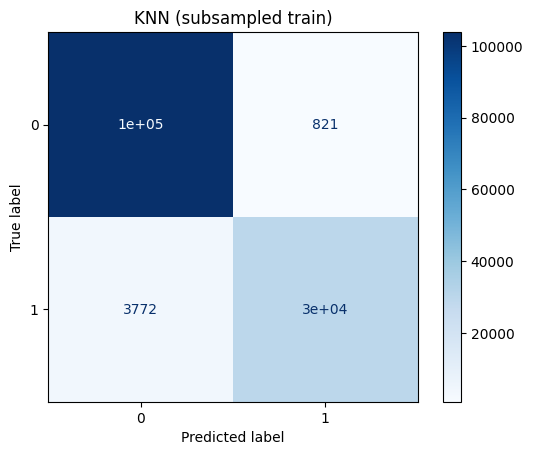

In [ ]:
# -------------------------------------------------------------
# 4. K-Nearest Neighbors — ~10–25 min (subsampled train)
# -------------------------------------------------------------
from sklearn.neighbors import KNeighborsClassifier

# KNN on full 400k train is too slow → use 60k stratified subsample
X_train_knn, _, y_train_knn, _ = train_test_split(
    X_train_current, y_train_current,
    train_size=60000, stratify=y_train_current, random_state=42
)

X_tune, _, y_tune, _ = train_test_split(
    X_train_knn, y_train_knn, train_size=0.3, stratify=y_train_knn, random_state=42
)

knn = KNeighborsClassifier(algorithm='ball_tree', n_jobs=-1)

param_grid = {
    'n_neighbors': [3,5,7,9],
    'weights': ['uniform','distance'],
    'p': [1,2]
}

grid = GridSearchCV(knn, param_grid, cv=3, scoring='f1', n_jobs=-1, verbose=1)
grid.fit(X_tune, y_tune)

best_knn = grid.best_estimator_
best_knn.fit(X_train_knn, y_train_knn)

print("KNN Best params:", grid.best_params_)
y_pred = best_knn.predict(X_test_current)
y_pred_proba = best_knn.predict_proba(X_test_current)[:,1]

print(f"Accuracy: {accuracy_score(y_test_current, y_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test_current, y_pred_proba):.4f}")
print(classification_report(y_test_current, y_pred))
report=classification_report(y_test_current, y_pred,output_dict=True)
cm = confusion_matrix(y_test_current, y_pred)
ConfusionMatrixDisplay(cm).plot(cmap='Blues')
plt.title("KNN (subsampled train)")
plt.show()

In [ ]:

evaluate_and_save_metrics(
    split_name=current_split_name,
    model_name="Knn",
    vectorizer_name="TF-IDF",
    y_true=y_test_current,
    y_pred=y_pred,
    notes="test_1"
)

SAVED → 70/30 split | Knn | f1_weighted=0.9661920594927197 | test_1


In [ ]:
y_pred = best_knn.predict(X_test_2)
report = classification_report(y_test_2, y_pred, output_dict=True)
evaluate_and_save_metrics(
    split_name=current_split_name,
    model_name="Knn",
    vectorizer_name="TF-IDF",
    y_true=y_test_2,
    y_pred=y_pred,
    notes="test_2"
)

SAVED → 70/30 split | Knn | f1_weighted=0.9717024283303096 | test_2


In [ ]:
y_pred = best_knn.predict(X_test_3)
report = classification_report(y_test_3, y_pred, output_dict=True)
evaluate_and_save_metrics(
    split_name=current_split_name,
    model_name="Knn",
    vectorizer_name="TF-IDF",
    y_true=y_test_3,
    y_pred=y_pred,
    notes="test_3"
)

SAVED → 70/30 split | Knn | f1_weighted=0.9843464864583553 | test_3


In [ ]:
y_pred = best_knn.predict(X_test_4)
report = classification_report(y_test_4, y_pred, output_dict=True)
evaluate_and_save_metrics(
    split_name=current_split_name,
    model_name="Knn",
    vectorizer_name="TF-IDF",
    y_true=y_test_4,
    y_pred=y_pred,
    notes="test_4"
)

SAVED → 70/30 split | Knn | f1_weighted=0.9910402882217948 | test_4


In [ ]:
y_pred = best_knn.predict(X_test_5)
report = classification_report(y_test_5, y_pred, output_dict=True)
evaluate_and_save_metrics(
    split_name=current_split_name,
    model_name="Knn",
    vectorizer_name="TF-IDF",
    y_true=y_test_5,
    y_pred=y_pred,
    notes="test_5"
)

SAVED → 70/30 split | Knn | f1_weighted=0.9909899393713979 | test_5


##5. Random forest

Fitting 3 folds for each of 25 candidates, totalling 75 fits


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.


building tree 1 of 154building tree 2 of 154

building tree 3 of 154
building tree 4 of 154
building tree 5 of 154
building tree 6 of 154
building tree 7 of 154
building tree 8 of 154
building tree 9 of 154
building tree 10 of 154
building tree 11 of 154
building tree 12 of 154
building tree 13 of 154
building tree 14 of 154
building tree 15 of 154
building tree 16 of 154
building tree 17 of 154
building tree 18 of 154
building tree 19 of 154
building tree 20 of 154
building tree 21 of 154
building tree 22 of 154
building tree 23 of 154
building tree 24 of 154
building tree 25 of 154
building tree 26 of 154
building tree 27 of 154
building tree 28 of 154
building tree 29 of 154
building tree 30 of 154
building tree 31 of 154
building tree 32 of 154
building tree 33 of 154
building tree 34 of 154
building tree 35 of 154
building tree 36 of 154
building tree 37 of 154
building tree 38 of 154
building tree 39 of 154


[Parallel(n_jobs=-1)]: Done  37 tasks      | elapsed:    4.1s


building tree 40 of 154
building tree 41 of 154
building tree 42 of 154
building tree 43 of 154
building tree 44 of 154
building tree 45 of 154
building tree 46 of 154
building tree 47 of 154
building tree 48 of 154
building tree 49 of 154
building tree 50 of 154
building tree 51 of 154
building tree 52 of 154
building tree 53 of 154
building tree 54 of 154
building tree 55 of 154
building tree 56 of 154
building tree 57 of 154
building tree 58 of 154
building tree 59 of 154
building tree 60 of 154
building tree 61 of 154
building tree 62 of 154
building tree 63 of 154
building tree 64 of 154
building tree 65 of 154
building tree 66 of 154
building tree 67 of 154
building tree 68 of 154
building tree 69 of 154
building tree 70 of 154
building tree 71 of 154
building tree 72 of 154
building tree 73 of 154
building tree 74 of 154
building tree 75 of 154
building tree 76 of 154
building tree 77 of 154
building tree 78 of 154
building tree 79 of 154
building tree 80 of 154
building tree 81

...

building tree 40 of 154
building tree 41 of 154
building tree 42 of 154
building tree 43 of 154
building tree 44 of 154
building tree 45 of 154
building tree 46 of 154
building tree 47 of 154
building tree 48 of 154
building tree 49 of 154
building tree 50 of 154
building tree 51 of 154
building tree 52 of 154
building tree 53 of 154
building tree 54 of 154
building tree 55 of 154
building tree 56 of 154
building tree 57 of 154
building tree 58 of 154
building tree 59 of 154
building tree 60 of 154
building tree 61 of 154
building tree 62 of 154
building tree 63 of 154
building tree 64 of 154
building tree 65 of 154
building tree 66 of 154
building tree 67 of 154
building tree 68 of 154
building tree 69 of 154
building tree 70 of 154
building tree 71 of 154
building tree 72 of 154
building tree 73 of 154
building tree 74 of 154
building tree 75 of 154
building tree 76 of 154
building tree 77 of 154
building tree 78 of 154
building tree 79 of 154
building tree 80 of 154
building tree 81

[Parallel(n_jobs=-1)]: Done 154 out of 154 | elapsed:  1.9min finished


RF Best params: {'max_depth': 30, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 4, 'n_estimators': 154}
OOB Score: 0.9990430053321202


[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  37 tasks      | elapsed:    0.4s
[Parallel(n_jobs=2)]: Done 154 out of 154 | elapsed:    1.8s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  37 tasks      | elapsed:    0.7s
[Parallel(n_jobs=2)]: Done 154 out of 154 | elapsed:    2.7s finished


Accuracy: 0.9964
ROC-AUC: 0.9993
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    104643
           1       1.00      0.99      0.99     33407

    accuracy                           1.00    138050
   macro avg       1.00      0.99      1.00    138050
weighted avg       1.00      1.00      1.00    138050



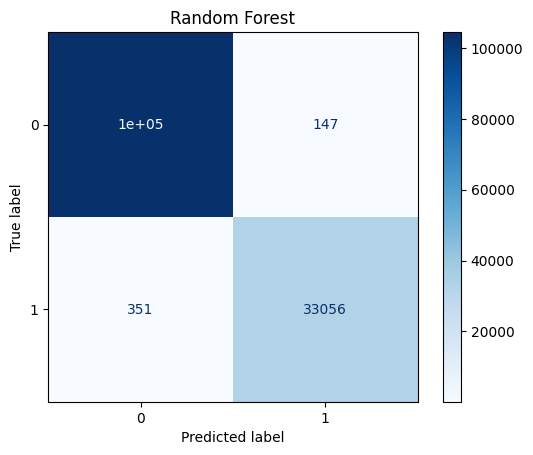

In [ ]:
# -------------------------------------------------------------
# 5. Random Forest — ~12–30 min total (best expected results)
# -------------------------------------------------------------
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

X_tune, _, y_tune, _ = train_test_split(
    X_train_current, y_train_current,
    train_size=0.2, stratify=y_train_current, random_state=42
)

rf = RandomForestClassifier(
    class_weight='balanced', random_state=42,
    n_jobs=-1, oob_score=True, max_samples=0.8, verbose=2
)

param_dist = {
    'n_estimators': randint(150, 350),
    'max_depth': [None, 20, 30],
    'min_samples_split': randint(2, 6),
    'min_samples_leaf': randint(1, 4),
    'max_features': ['sqrt', 'log2']
}

search = RandomizedSearchCV(rf, param_dist, n_iter=25, cv=3,
                            scoring='f1', n_jobs=-1, verbose=2, random_state=42)
search.fit(X_tune, y_tune)

best_rf = search.best_estimator_
best_rf.fit(X_train_current, y_train_current)

print("RF Best params:", search.best_params_)
print("OOB Score:", best_rf.oob_score_)

y_pred = best_rf.predict(X_test_current)
y_pred_proba = best_rf.predict_proba(X_test_current)[:,1]

print(f"Accuracy: {accuracy_score(y_test_current, y_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test_current, y_pred_proba):.4f}")
print(classification_report(y_test_current, y_pred))
report=classification_report(y_test_current, y_pred,output_dict=True)

cm = confusion_matrix(y_test_current, y_pred)
ConfusionMatrixDisplay(cm).plot(cmap='Blues')
plt.title("Random Forest")
plt.show()

In [ ]:

evaluate_and_save_metrics(
    split_name=current_split_name,
    model_name="RandomForest",
    vectorizer_name="TF-IDF",
    y_true=y_test_current,
    y_pred=y_pred,
    notes="test_1"
)


SAVED → 70/30 split | RandomForest | f1_weighted=0.9963888437984872 | test_1


In [ ]:
y_pred = best_rf.predict(X_test_2)
report = classification_report(y_test_2, y_pred, output_dict=True)
evaluate_and_save_metrics(
    split_name=current_split_name,
    model_name="RandomForest",
    vectorizer_name="TF-IDF",
    y_true=y_test_2,
    y_pred=y_pred,
    notes="test_2"
)

[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  37 tasks      | elapsed:    1.3s
[Parallel(n_jobs=2)]: Done 154 out of 154 | elapsed:    5.5s finished


SAVED → 70/30 split | RandomForest | f1_weighted=0.9965237896459557 | test_2


In [ ]:
y_pred = best_rf.predict(X_test_3)
report = classification_report(y_test_3, y_pred, output_dict=True)
evaluate_and_save_metrics(
    split_name=current_split_name,
    model_name="RandomForest",
    vectorizer_name="TF-IDF",
    y_true=y_test_3,
    y_pred=y_pred,
    notes="test_3"
)

[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  37 tasks      | elapsed:    1.3s
[Parallel(n_jobs=2)]: Done 154 out of 154 | elapsed:    6.4s finished


SAVED → 70/30 split | RandomForest | f1_weighted=0.7624236203401575 | test_3


In [ ]:
y_pred = best_rf.predict(X_test_4)
report = classification_report(y_test_4, y_pred, output_dict=True)
evaluate_and_save_metrics(
    split_name=current_split_name,
    model_name="RandomForest",
    vectorizer_name="TF-IDF",
    y_true=y_test_4,
    y_pred=y_pred,
    notes="test_4"
)

[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  37 tasks      | elapsed:    1.4s
[Parallel(n_jobs=2)]: Done 154 out of 154 | elapsed:    5.6s finished


SAVED → 70/30 split | RandomForest | f1_weighted=0.9966982338371453 | test_4


In [ ]:
y_pred = best_rf.predict(X_test_5)
report = classification_report(y_test_5, y_pred, output_dict=True)
evaluate_and_save_metrics(
    split_name=current_split_name,
    model_name="RandomForest",
    vectorizer_name="TF-IDF",
    y_true=y_test_5,
    y_pred=y_pred,
    notes="test_5"
)

[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  37 tasks      | elapsed:    1.3s
[Parallel(n_jobs=2)]: Done 154 out of 154 | elapsed:    6.6s finished


SAVED → 70/30 split | RandomForest | f1_weighted=0.9941470274342593 | test_5


# Unsupervised

##K-Means

### Subtask:
Apply K-Means clustering to each of the three train/test splits (50/50, 70/30, and 80/20), then evaluate its performance using ROC AUC and F1-score.

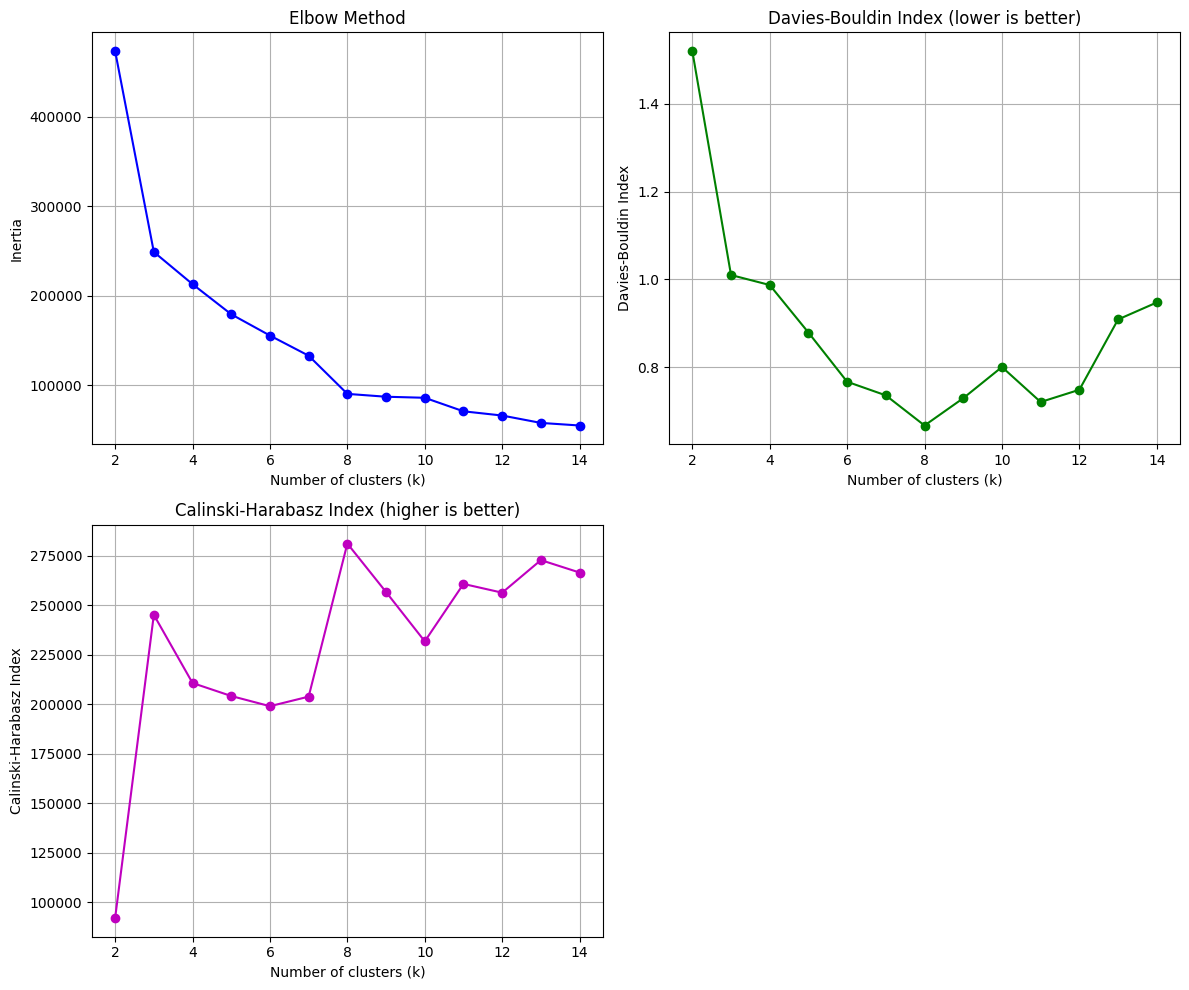

KMeans, roc_auc_score, and f1_score imported successfully.


In [ ]:
# methods to determine k
from sklearn.cluster import KMeans
from sklearn.metrics import roc_auc_score, f1_score

from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score
import numpy as np # Ensure numpy is imported for np.nan

def find_optimal_k(X, k_range):
    inertia = []
    davies_bouldin = []
    calinski_harabasz = []
    k_values = []

    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
        kmeans.fit(X)
        labels = kmeans.labels_

        inertia.append(kmeans.inertia_)
        k_values.append(k)

        # Metrics that require at least 2 clusters
        if k > 1:
            davies_bouldin.append(davies_bouldin_score(X, labels))
            calinski_harabasz.append(calinski_harabasz_score(X, labels))
        else:
            # For k=1, these metrics are not defined, so append NaN
            davies_bouldin.append(np.nan)
            calinski_harabasz.append(np.nan)

    return {
        'k_values': k_values,
        'inertia': inertia,
        'davies_bouldin': davies_bouldin,
        'calinski_harabasz': calinski_harabasz
    }

# elbow method
# Find optimal k
k_range = range(2, 15)
results = find_optimal_k(X_train_current, k_range) # Changed X_train_scaled to X_train_current
# Plotting results
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Plot inertia (Elbow method)
axes[0, 0].plot(results['k_values'], results['inertia'], 'bo-')
axes[0, 0].set_xlabel('Number of clusters (k)')
axes[0, 0].set_ylabel('Inertia')
axes[0, 0].set_title('Elbow Method')
axes[0, 0].grid(True)

# Plot Davies-Bouldin index
axes[0, 1].plot(results['k_values'], results['davies_bouldin'], 'go-')
axes[0, 1].set_xlabel('Number of clusters (k)')
axes[0, 1].set_ylabel('Davies-Bouldin Index')
axes[0, 1].set_title('Davies-Bouldin Index (lower is better)')
axes[0, 1].grid(True)

# Plot Calinski-Harabasz index
axes[1, 0].plot(results['k_values'], results['calinski_harabasz'], 'mo-')
axes[1, 0].set_xlabel('Number of clusters (k)')
axes[1, 0].set_ylabel('Calinski-Harabasz Index')
axes[1, 0].set_title('Calinski-Harabasz Index (higher is better)')
axes[1, 0].grid(True)

fig.delaxes(axes[1, 1])
plt.tight_layout()
plt.show()
print("KMeans, roc_auc_score, and f1_score imported successfully.")

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, classification_report, confusion_matrix
import numpy as np

kmeans_results = {}


print(f"\nApplying K-Means to {current_split_name}...")

# Instantiate KMeans
kmeans = KMeans(n_clusters=9, random_state=42, n_init='auto')

# Train K-Means on the training data
kmeans.fit(X_train_current)

# Predict cluster labels for the test data
y_pred_clusters = kmeans.predict(X_test_current)

# Map cluster labels to actual labels (0 for Benign, 1 for Malicious)
# Determine which cluster corresponds to 'Benign' (0) and 'Malicious' (1)
# by checking the majority class within each cluster in y_test

cluster_to_binary_label = {}
unique_clusters_found = np.unique(y_pred_clusters)

for cluster_id in unique_clusters_found:
    # Get the true labels for points belonging to this cluster
    true_labels_in_cluster = y_test_current[y_pred_clusters == cluster_id]

    if len(true_labels_in_cluster) > 0:
        # Count benign (0) and malicious (1) instances in this cluster
        benign_count = (true_labels_in_cluster == 0).sum()
        malicious_count = (true_labels_in_cluster == 1).sum()

        # Assign the binary label (0 or 1) to this cluster based on the majority class
        if benign_count >= malicious_count:
            cluster_to_binary_label[cluster_id] = 0  # Map to Benign
        else:
            cluster_to_binary_label[cluster_id] = 1  # Map to Malicious
    else:
        # Fallback for empty clusters (unlikely with KMeans, but good for robustness)
        cluster_to_binary_label[cluster_id] = 1 # Default to malicious

y_pred_mapped = np.array([cluster_to_binary_label[pred_cluster] for pred_cluster in y_pred_clusters])

# Additional metrics requested by the user

# Accuracy
accuracy = accuracy_score(y_test_current, y_pred_mapped)
print(f"\nAccuracy: {accuracy:.4f}")

# Classification report (precision, recall, f1, support)
print("\nClassification Report:")
print(classification_report(y_test_current, y_pred_mapped))


# Confusion matrix
cm = confusion_matrix(y_test_current, y_pred_mapped)
print("\nConfusion Matrix:")
print(cm)

print("\nK-Means clustering and evaluation complete for the selected split.")
# The kmeans_results dictionary was empty, removing the print for now unless it gets populated.


Applying K-Means to 50/50 split...

Accuracy: 0.8363

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.96      0.90    174177
           1       0.80      0.44      0.57     55906

    accuracy                           0.84    230083
   macro avg       0.82      0.70      0.73    230083
weighted avg       0.83      0.84      0.82    230083


Confusion Matrix:
[[167894   6283]
 [ 31392  24514]]

K-Means clustering and evaluation complete for the selected split.


In [ ]:

evaluate_and_save_metrics(
    split_name=current_split_name,
    model_name="K-means",
    vectorizer_name="TF-IDF",
    y_true=y_test_current,
    y_pred=y_pred_mapped,
    notes="test_1"
)

SAVED → 50/50 split | K-means | f1_weighted=0.8180491420333234 | test_1


In [ ]:
y_pred_clusters = kmeans.predict(X_test_2)

# Map cluster labels to actual labels (0 for Benign, 1 for Malicious)
# Determine which cluster corresponds to 'Benign' (0) and 'Malicious' (1)
# by checking the majority class within each cluster in y_test

cluster_to_binary_label = {}
unique_clusters_found = np.unique(y_pred_clusters)

for cluster_id in unique_clusters_found:
    # Get the true labels for points belonging to this cluster
    true_labels_in_cluster = y_test_2[y_pred_clusters == cluster_id]

    if len(true_labels_in_cluster) > 0:
        # Count benign (0) and malicious (1) instances in this cluster
        benign_count = (true_labels_in_cluster == 0).sum()
        malicious_count = (true_labels_in_cluster == 1).sum()

        # Assign the binary label (0 or 1) to this cluster based on the majority class
        if benign_count >= malicious_count:
            cluster_to_binary_label[cluster_id] = 0  # Map to Benign
        else:
            cluster_to_binary_label[cluster_id] = 1  # Map to Malicious
    else:
        # Fallback for empty clusters (unlikely with KMeans, but good for robustness)
        cluster_to_binary_label[cluster_id] = 1 # Default to malicious

y_pred_mapped = np.array([cluster_to_binary_label[pred_cluster] for pred_cluster in y_pred_clusters])
report = classification_report(y_test_2, y_pred_mapped, output_dict=True)

In [ ]:
evaluate_and_save_metrics(
    split_name=current_split_name,
    model_name="K-means",
    vectorizer_name="TF-IDF",
    y_true=y_test_2,
    y_pred=y_pred_mapped,
    notes="test_2"
)

SAVED → 50/50 split | K-means | f1_weighted=0.774391719405244 | test_2


In [ ]:
y_pred_clusters = kmeans.predict(X_test_3)

# Map cluster labels to actual labels (0 for Benign, 1 for Malicious)
# Determine which cluster corresponds to 'Benign' (0) and 'Malicious' (1)
# by checking the majority class within each cluster in y_test

cluster_to_binary_label = {}
unique_clusters_found = np.unique(y_pred_clusters)

for cluster_id in unique_clusters_found:
    # Get the true labels for points belonging to this cluster
    true_labels_in_cluster = y_test_3[y_pred_clusters == cluster_id]

    if len(true_labels_in_cluster) > 0:
        # Count benign (0) and malicious (1) instances in this cluster
        benign_count = (true_labels_in_cluster == 0).sum()
        malicious_count = (true_labels_in_cluster == 1).sum()

        # Assign the binary label (0 or 1) to this cluster based on the majority class
        if benign_count >= malicious_count:
            cluster_to_binary_label[cluster_id] = 0  # Map to Benign
        else:
            cluster_to_binary_label[cluster_id] = 1  # Map to Malicious
    else:
        # Fallback for empty clusters (unlikely with KMeans, but good for robustness)
        cluster_to_binary_label[cluster_id] = 1 # Default to malicious

y_pred_mapped = np.array([cluster_to_binary_label[pred_cluster] for pred_cluster in y_pred_clusters])
report = classification_report(y_test_3, y_pred_mapped, output_dict=True)

In [ ]:

evaluate_and_save_metrics(
    split_name=current_split_name,
    model_name="K-means",
    vectorizer_name="TF-IDF",
    y_true=y_test_3,
    y_pred=y_pred_mapped,
    notes="test_3"
)

SAVED → 50/50 split | K-means | f1_weighted=0.7750854237606609 | test_3


In [ ]:
y_pred_clusters = kmeans.predict(X_test_4)

# Map cluster labels to actual labels (0 for Benign, 1 for Malicious)
# Determine which cluster corresponds to 'Benign' (0) and 'Malicious' (1)
# by checking the majority class within each cluster in y_test

cluster_to_binary_label = {}
unique_clusters_found = np.unique(y_pred_clusters)

for cluster_id in unique_clusters_found:
    # Get the true labels for points belonging to this cluster
    true_labels_in_cluster = y_test_4[y_pred_clusters == cluster_id]

    if len(true_labels_in_cluster) > 0:
        # Count benign (0) and malicious (1) instances in this cluster
        benign_count = (true_labels_in_cluster == 0).sum()
        malicious_count = (true_labels_in_cluster == 1).sum()

        # Assign the binary label (0 or 1) to this cluster based on the majority class
        if benign_count >= malicious_count:
            cluster_to_binary_label[cluster_id] = 0  # Map to Benign
        else:
            cluster_to_binary_label[cluster_id] = 1  # Map to Malicious
    else:
        # Fallback for empty clusters (unlikely with KMeans, but good for robustness)
        cluster_to_binary_label[cluster_id] = 1 # Default to malicious

y_pred_mapped = np.array([cluster_to_binary_label[pred_cluster] for pred_cluster in y_pred_clusters])
report = classification_report(y_test_4, y_pred_mapped, output_dict=True)

In [ ]:

evaluate_and_save_metrics(
    split_name=current_split_name,
    model_name="K-means",
    vectorizer_name="TF-IDF",
    y_true=y_test_4,
    y_pred=y_pred_mapped,
    notes="test_4"
)

SAVED → 50/50 split | K-means | f1_weighted=0.7755746300042983 | test_4


In [ ]:
y_pred_clusters = kmeans.predict(X_test_5)

# Map cluster labels to actual labels (0 for Benign, 1 for Malicious)
# Determine which cluster corresponds to 'Benign' (0) and 'Malicious' (1)
# by checking the majority class within each cluster in y_test

cluster_to_binary_label = {}
unique_clusters_found = np.unique(y_pred_clusters)

for cluster_id in unique_clusters_found:
    # Get the true labels for points belonging to this cluster
    true_labels_in_cluster = y_test_5[y_pred_clusters == cluster_id]

    if len(true_labels_in_cluster) > 0:
        # Count benign (0) and malicious (1) instances in this cluster
        benign_count = (true_labels_in_cluster == 0).sum()
        malicious_count = (true_labels_in_cluster == 1).sum()

        # Assign the binary label (0 or 1) to this cluster based on the majority class
        if benign_count >= malicious_count:
            cluster_to_binary_label[cluster_id] = 0  # Map to Benign
        else:
            cluster_to_binary_label[cluster_id] = 1  # Map to Malicious
    else:
        # Fallback for empty clusters (unlikely with KMeans, but good for robustness)
        cluster_to_binary_label[cluster_id] = 1 # Default to malicious

y_pred_mapped = np.array([cluster_to_binary_label[pred_cluster] for pred_cluster in y_pred_clusters])
report = classification_report(y_test_5, y_pred_mapped, output_dict=True)

In [ ]:

evaluate_and_save_metrics(
    split_name=current_split_name,
    model_name="K-means",
    vectorizer_name="TF-IDF",
    y_true=y_test_5,
    y_pred=y_pred_mapped,
    notes="test_5"
)

SAVED → 50/50 split | K-means | f1_weighted=0.7748034424474186 | test_5


## PCA20-HDBSCAN

Apply PCA with **20** components to the test data (`X_test_current`).

In [ ]:
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, classification_report, confusion_matrix, precision_score
import hdbscan
import numpy as np
from sklearn.decomposition import PCA

# ---------------------------------------------------------
# STEP 1: Apply PCA with 20 components
# ---------------------------------------------------------
print("Applying PCA with 20 components to X_test_current for HDBSCAN...")
pca_hdbscan = PCA(n_components=10, random_state=42)

# Fit PCA on X_train_current to learn the components from the training distribution
# Then transform X_test_current
# Note: X_train_current is available from previous cells
pca_hdbscan.fit(X_train_current)
X_test_for_hdbscan = pca_hdbscan.transform(X_test_current)

print(f"Data shape for HDBSCAN after PCA: {X_test_for_hdbscan.shape}")

# ---------------------------------------------------------
# STEP 2: HDBSCAN CLUSTERING
# ---------------------------------------------------------
# Your parameters are high (1000), make sure your dataset is large (>50k rows)
hdbscan_clusterer = hdbscan.HDBSCAN(min_cluster_size=1000, min_samples=50, metric='euclidean')

# We fit HDBSCAN on the test data (this is okay, it's unsupervised)
hdbscan_clusterer.fit(X_test_for_hdbscan)
hdbscan_labels = hdbscan_clusterer.labels_

n_clusters = len(np.unique(hdbscan_labels)) - (1 if -1 in hdbscan_labels else 0)
n_noise = (hdbscan_labels == -1).sum()

print(f"HDBSCAN found {n_clusters} clusters and {n_noise} noise points.")

# ---------------------------------------------------------
# STEP 3: MAPPING & EVALUATION
# ---------------------------------------------------------
unique_clusters = np.unique(hdbscan_labels[hdbscan_labels != -1])
cluster_to_binary_label = {}

for cluster_id in unique_clusters:
    # Get the indices of points in this cluster
    indices = np.where(hdbscan_labels == cluster_id)[0]

    # Get the TRUE labels for these points
    true_labels_in_cluster = y_test_current[indices]

    if len(true_labels_in_cluster) > 0:
        # Calculate purity
        benign_count = (true_labels_in_cluster == 0).sum()
        malicious_count = (true_labels_in_cluster == 1).sum()

        # Assign label based on majority
        if benign_count >= malicious_count:
            cluster_to_binary_label[cluster_id] = 0
        else:
            cluster_to_binary_label[cluster_id] = 1
    else:
        cluster_to_binary_label[cluster_id] = 1 # Fallback

# Map Noise (-1) to Malicious (1) - Good strategy for security
cluster_to_binary_label[-1] = 1

# Generate Predictions
y_pred_hdbscan = np.array([cluster_to_binary_label[label] for label in hdbscan_labels])

# ---------------------------------------------------------
# STEP 4: RESULTS
# ---------------------------------------------------------

print(f"\n--- HDBSCAN Results (with PCA 20 components) ---")
print(f"ROC AUC:  {roc_auc_score(y_test_current, y_pred_hdbscan):.4f}")
print(f"F1 Score: {f1_score(y_test_current, y_pred_hdbscan):.4f}")
print(f"Accuracy: {accuracy_score(y_test_current, y_pred_hdbscan):.4f}")
print(f"Precision: {precision_score(y_test_current, y_pred_hdbscan):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_current, y_pred_hdbscan))

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


Applying PCA with 20 components to X_test_current for HDBSCAN...
Data shape for HDBSCAN after PCA: (230083, 10)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


HDBSCAN found 46 clusters and 49483 noise points.

--- HDBSCAN Results (with PCA 20 components) ---
ROC AUC:  0.8237
F1 Score: 0.6631
Accuracy: 0.7716
Precision: 0.5167

Confusion Matrix:
[[125815  48362]
 [  4192  51714]]


In [ ]:
report = classification_report(y_test_current,y_pred_hdbscan,output_dict=True)

evaluate_and_save_metrics(
    split_name=current_split_name,
    model_name="HDBSCAN",
    vectorizer_name="PCA",
    y_true=y_test_current,
    y_pred=y_pred_hdbscan,
    notes="test_1"
)

SAVED → 50/50 split | HDBSCAN | f1_weighted=0.7873433517068665 | test_1


In [ ]:
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, classification_report, confusion_matrix, precision_score
import hdbscan
import numpy as np
from sklearn.decomposition import PCA

# ---------------------------------------------------------
# STEP 1: Apply PCA with 20 components
# ---------------------------------------------------------
print("Applying PCA with 20 components to X_test_current for HDBSCAN...")
pca_hdbscan = PCA(n_components=10, random_state=42)

# Fit PCA on X_train_current to learn the components from the training distribution
# Then transform X_test_current
# Note: X_train_current is available from previous cells
pca_hdbscan.fit(X_train_current)
X_test_for_hdbscan = pca_hdbscan.transform(X_test_2)

hdbscan_clusterer = hdbscan.HDBSCAN(min_cluster_size=1000, min_samples=50, metric='euclidean')

hdbscan_clusterer.fit(X_test_for_hdbscan)
hdbscan_labels = hdbscan_clusterer.labels_

n_clusters = len(np.unique(hdbscan_labels)) - (1 if -1 in hdbscan_labels else 0)
n_noise = (hdbscan_labels == -1).sum()

unique_clusters = np.unique(hdbscan_labels[hdbscan_labels != -1])
cluster_to_binary_label = {}

for cluster_id in unique_clusters:
    # Get the indices of points in this cluster
    indices = np.where(hdbscan_labels == cluster_id)[0]

    # Get the TRUE labels for these points
    true_labels_in_cluster = y_test_2[indices]

    if len(true_labels_in_cluster) > 0:
        # Calculate purity
        benign_count = (true_labels_in_cluster == 0).sum()
        malicious_count = (true_labels_in_cluster == 1).sum()

        # Assign label based on majority
        if benign_count >= malicious_count:
            cluster_to_binary_label[cluster_id] = 0
        else:
            cluster_to_binary_label[cluster_id] = 1
    else:
        cluster_to_binary_label[cluster_id] = 1 # Fallback

# Map Noise (-1) to Malicious (1) - Good strategy for security
cluster_to_binary_label[-1] = 1

# Generate Predictions
y_pred_hdbscan = np.array([cluster_to_binary_label[label] for label in hdbscan_labels])

report = classification_report(y_test_2,y_pred_hdbscan,output_dict=True)

evaluate_and_save_metrics(
    split_name=current_split_name,
    model_name="HDBSCAN",
    vectorizer_name="PCA",
    y_true=y_test_2,
    y_pred=y_pred_hdbscan,
    notes="test_2"
)


Applying PCA with 20 components to X_test_current for HDBSCAN...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


SAVED → 50/50 split | HDBSCAN | f1_weighted=0.7464751615754931 | test_2


In [ ]:
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, classification_report, confusion_matrix, precision_score
import hdbscan
import numpy as np
from sklearn.decomposition import PCA

# ---------------------------------------------------------
# STEP 1: Apply PCA with 20 components
# ---------------------------------------------------------
print("Applying PCA with 20 components to X_test_current for HDBSCAN...")
pca_hdbscan = PCA(n_components=10, random_state=42)

# Fit PCA on X_train_current to learn the components from the training distribution
# Then transform X_test_current
# Note: X_train_current is available from previous cells
pca_hdbscan.fit(X_train_current)
X_test_for_hdbscan = pca_hdbscan.transform(X_test_3)

hdbscan_clusterer = hdbscan.HDBSCAN(min_cluster_size=1000, min_samples=50, metric='euclidean')

hdbscan_clusterer.fit(X_test_for_hdbscan)
hdbscan_labels = hdbscan_clusterer.labels_

n_clusters = len(np.unique(hdbscan_labels)) - (1 if -1 in hdbscan_labels else 0)
n_noise = (hdbscan_labels == -1).sum()

unique_clusters = np.unique(hdbscan_labels[hdbscan_labels != -1])
cluster_to_binary_label = {}

for cluster_id in unique_clusters:
    # Get the indices of points in this cluster
    indices = np.where(hdbscan_labels == cluster_id)[0]

    # Get the TRUE labels for these points
    true_labels_in_cluster = y_test_3[indices]

    if len(true_labels_in_cluster) > 0:
        # Calculate purity
        benign_count = (true_labels_in_cluster == 0).sum()
        malicious_count = (true_labels_in_cluster == 1).sum()

        # Assign label based on majority
        if benign_count >= malicious_count:
            cluster_to_binary_label[cluster_id] = 0
        else:
            cluster_to_binary_label[cluster_id] = 1
    else:
        cluster_to_binary_label[cluster_id] = 1 # Fallback

# Map Noise (-1) to Malicious (1) - Good strategy for security
cluster_to_binary_label[-1] = 1

# Generate Predictions
y_pred_hdbscan = np.array([cluster_to_binary_label[label] for label in hdbscan_labels])

report = classification_report(y_test_3,y_pred_hdbscan,output_dict=True)
evaluate_and_save_metrics(
    split_name=current_split_name,
    model_name="HDBSCAN",
    vectorizer_name="PCA",
    y_true=y_test_3,
    y_pred=y_pred_hdbscan,
    notes="test_3"
)


Applying PCA with 20 components to X_test_current for HDBSCAN...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


SAVED → 50/50 split | HDBSCAN | f1_weighted=0.7833148050763941 | test_3


In [ ]:
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, classification_report, confusion_matrix, precision_score
import hdbscan
import numpy as np
from sklearn.decomposition import PCA

# ---------------------------------------------------------
# STEP 1: Apply PCA with 20 components
# ---------------------------------------------------------
print("Applying PCA with 20 components to X_test_current for HDBSCAN...")
pca_hdbscan = PCA(n_components=10, random_state=42)

# Fit PCA on X_train_current to learn the components from the training distribution
# Then transform X_test_current
# Note: X_train_current is available from previous cells
pca_hdbscan.fit(X_train_current)
X_test_for_hdbscan = pca_hdbscan.transform(X_test_4)

hdbscan_clusterer = hdbscan.HDBSCAN(min_cluster_size=1000, min_samples=50, metric='euclidean')

hdbscan_clusterer.fit(X_test_for_hdbscan)
hdbscan_labels = hdbscan_clusterer.labels_

n_clusters = len(np.unique(hdbscan_labels)) - (1 if -1 in hdbscan_labels else 0)
n_noise = (hdbscan_labels == -1).sum()

unique_clusters = np.unique(hdbscan_labels[hdbscan_labels != -1])
cluster_to_binary_label = {}

for cluster_id in unique_clusters:
    # Get the indices of points in this cluster
    indices = np.where(hdbscan_labels == cluster_id)[0]

    # Get the TRUE labels for these points
    true_labels_in_cluster = y_test_4[indices]

    if len(true_labels_in_cluster) > 0:
        # Calculate purity
        benign_count = (true_labels_in_cluster == 0).sum()
        malicious_count = (true_labels_in_cluster == 1).sum()

        # Assign label based on majority
        if benign_count >= malicious_count:
            cluster_to_binary_label[cluster_id] = 0
        else:
            cluster_to_binary_label[cluster_id] = 1
    else:
        cluster_to_binary_label[cluster_id] = 1 # Fallback

# Map Noise (-1) to Malicious (1) - Good strategy for security
cluster_to_binary_label[-1] = 1

# Generate Predictions
y_pred_hdbscan = np.array([cluster_to_binary_label[label] for label in hdbscan_labels])

report = classification_report(y_test_4,y_pred_hdbscan,output_dict=True)
evaluate_and_save_metrics(
    split_name=current_split_name,
    model_name="HDBSCAN",
    vectorizer_name="PCA",
    y_true=y_test_4,
    y_pred=y_pred_hdbscan,
    notes="test_4"
)

Applying PCA with 20 components to X_test_current for HDBSCAN...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


SAVED → 50/50 split | HDBSCAN | f1_weighted=0.7714389403569515 | test_4


In [ ]:
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, classification_report, confusion_matrix, precision_score
import hdbscan
import numpy as np
from sklearn.decomposition import PCA

# ---------------------------------------------------------
# STEP 1: Apply PCA with 20 components
# ---------------------------------------------------------
print("Applying PCA with 20 components to X_test_current for HDBSCAN...")
pca_hdbscan = PCA(n_components=10, random_state=42)

# Fit PCA on X_train_current to learn the components from the training distribution
# Then transform X_test_current
# Note: X_train_current is available from previous cells
pca_hdbscan.fit(X_train_current)
X_test_for_hdbscan = pca_hdbscan.transform(X_test_5)

hdbscan_clusterer = hdbscan.HDBSCAN(min_cluster_size=1000, min_samples=50, metric='euclidean')

hdbscan_clusterer.fit(X_test_for_hdbscan)
hdbscan_labels = hdbscan_clusterer.labels_

n_clusters = len(np.unique(hdbscan_labels)) - (1 if -1 in hdbscan_labels else 0)
n_noise = (hdbscan_labels == -1).sum()

unique_clusters = np.unique(hdbscan_labels[hdbscan_labels != -1])
cluster_to_binary_label = {}

for cluster_id in unique_clusters:
    # Get the indices of points in this cluster
    indices = np.where(hdbscan_labels == cluster_id)[0]

    # Get the TRUE labels for these points
    true_labels_in_cluster = y_test_5[indices]

    if len(true_labels_in_cluster) > 0:
        # Calculate purity
        benign_count = (true_labels_in_cluster == 0).sum()
        malicious_count = (true_labels_in_cluster == 1).sum()

        # Assign label based on majority
        if benign_count >= malicious_count:
            cluster_to_binary_label[cluster_id] = 0
        else:
            cluster_to_binary_label[cluster_id] = 1
    else:
        cluster_to_binary_label[cluster_id] = 1 # Fallback

# Map Noise (-1) to Malicious (1) - Good strategy for security
cluster_to_binary_label[-1] = 1

# Generate Predictions
y_pred_hdbscan = np.array([cluster_to_binary_label[label] for label in hdbscan_labels])

report = classification_report(y_test_5,y_pred_hdbscan,output_dict=True)
evaluate_and_save_metrics(
    split_name=current_split_name,
    model_name="HDBSCAN",
    vectorizer_name="PCA",
    y_true=y_test_5,
    y_pred=y_pred_hdbscan,
    notes="test_5"
)

Applying PCA with 20 components to X_test_current for HDBSCAN...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


SAVED → 50/50 split | HDBSCAN | f1_weighted=0.7706474366723091 | test_5


## IsolationForest

In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import numpy as np # Ensure numpy is imported for np.percentile

# Using the current split variables
X_train = X_train_current
X_test = X_test_current
y_train = y_train_current
y_test = y_test_current

print(f"Applying IsolationForest to {current_split_name}...")

# Step 1: Train ONLY on (mostly) benign traffic
# First make sure X_train has almost no attacks
benign_ratio = (y_train == 0).mean()
print(f"Benign ratio in train: {benign_ratio:.4f}")  # should be >0.98

X_train_benign = X_train[y_train == 0]   # Purge the few attacks if any

iso = IsolationForest(
    n_estimators=200,
    contamination=0.169,   # expected attack ratio (tune this!)
    max_samples=512,
    max_features=1.0,
    random_state=42,
    n_jobs=-1
)

print("Fitting IsolationForest on benign training data...")
iso.fit(X_train_benign)
print("IsolationForest training complete.")

# Step 2: Predict anomaly scores
print("Predicting anomaly scores...")
train_scores = iso.score_samples(X_train_benign)      # more negative = more anomalous
test_scores  = iso.score_samples(X_test)
print("Anomaly scores predicted.")

# Step 3: Convert to binary prediction (tune threshold on val set or use decision_function)
threshold = np.percentile(train_scores, 0.5)   # top 5% most anomalous in training = attack
# Or use: threshold = iso.offset_ # iso.offset_ can be used as a pre-computed threshold

y_pred_test = (test_scores < threshold).astype(int)

print("\nIsolationForest Performance Metrics:")
print("Classification Report:")
print(classification_report(y_test, y_pred_test, digits=4))
print("AUC:", roc_auc_score(y_test, -test_scores))   # negative because lower score = anomaly

# Add Confusion Matrix
cm = confusion_matrix(y_test, y_pred_test)
print("\nConfusion Matrix:")
print(cm)

print("\nIsolationForest process complete.")

Applying IsolationForest to 50/50 split...
Benign ratio in train: 0.5000
Fitting IsolationForest on benign training data...
IsolationForest training complete.
Predicting anomaly scores...
Anomaly scores predicted.

IsolationForest Performance Metrics:
Classification Report:
              precision    recall  f1-score   support

           0     0.7992    0.9912    0.8849    174177
           1     0.8905    0.2241    0.3581     55906

    accuracy                         0.8048    230083
   macro avg     0.8448    0.6076    0.6215    230083
weighted avg     0.8214    0.8048    0.7569    230083

AUC: 0.7295698521870582

Confusion Matrix:
[[172636   1541]
 [ 43376  12530]]

IsolationForest process complete.


In [ ]:
report = classification_report(y_test,y_pred_test,output_dict=True)
evaluate_and_save_metrics(
    split_name=current_split_name,
    model_name="IsolationForest",
    vectorizer_name="TF-IDF",
    y_true=y_test,
    y_pred=y_pred_test,
    notes="test_1"
)

SAVED → 50/50 split | IsolationForest | f1_weighted=0.7568893199378368 | test_1


In [ ]:
# Using the current split variables
X_train = X_train_current
X_test = X_test_2
y_train = y_train_current
y_test = y_test_2

print(f"Applying IsolationForest to {current_split_name}...")

# Step 1: Train ONLY on (mostly) benign traffic
# First make sure X_train has almost no attacks
benign_ratio = (y_train == 0).mean()
print(f"Benign ratio in train: {benign_ratio:.4f}")  # should be >0.98

X_train_benign = X_train[y_train == 0]   # Purge the few attacks if any

iso = IsolationForest(
    n_estimators=200,
    contamination=0.169,   # expected attack ratio (tune this!)
    max_samples=512,
    max_features=1.0,
    random_state=42,
    n_jobs=-1
)

print("Fitting IsolationForest on benign training data...")
iso.fit(X_train_benign)
print("IsolationForest training complete.")

# Step 2: Predict anomaly scores
print("Predicting anomaly scores...")
train_scores = iso.score_samples(X_train_benign)      # more negative = more anomalous
test_scores  = iso.score_samples(X_test)
print("Anomaly scores predicted.")

# Step 3: Convert to binary prediction (tune threshold on val set or use decision_function)
threshold = np.percentile(train_scores, 0.5)   # top 5% most anomalous in training = attack
# Or use: threshold = iso.offset_ # iso.offset_ can be used as a pre-computed threshold

y_pred_test = (test_scores < threshold).astype(int)
evaluate_and_save_metrics(
    split_name=current_split_name,
    model_name="IsolationForest",
    vectorizer_name="TF-IDF",
    y_true=y_test,
    y_pred=y_pred_test,
    notes="test_2"
)

In [ ]:
# Using the current split variables
X_train = X_train_current
X_test = X_test_3
y_train = y_train_current
y_test = y_test_3

print(f"Applying IsolationForest to {current_split_name}...")

# Step 1: Train ONLY on (mostly) benign traffic
# First make sure X_train has almost no attacks
benign_ratio = (y_train == 0).mean()
print(f"Benign ratio in train: {benign_ratio:.4f}")  # should be >0.98

X_train_benign = X_train[y_train == 0]   # Purge the few attacks if any

iso = IsolationForest(
    n_estimators=200,
    contamination=0.169,   # expected attack ratio (tune this!)
    max_samples=512,
    max_features=1.0,
    random_state=42,
    n_jobs=-1
)

print("Fitting IsolationForest on benign training data...")
iso.fit(X_train_benign)
print("IsolationForest training complete.")

# Step 2: Predict anomaly scores
print("Predicting anomaly scores...")
train_scores = iso.score_samples(X_train_benign)      # more negative = more anomalous
test_scores  = iso.score_samples(X_test)
print("Anomaly scores predicted.")

# Step 3: Convert to binary prediction (tune threshold on val set or use decision_function)
threshold = np.percentile(train_scores, 0.5)   # top 5% most anomalous in training = attack
# Or use: threshold = iso.offset_ # iso.offset_ can be used as a pre-computed threshold

y_pred_test = (test_scores < threshold).astype(int)
report = classification_report(y_test_3,y_pred_test,output_dict=True)
evaluate_and_save_metrics(
    split_name=current_split_name,
    model_name="IsolationForest",
    vectorizer_name="TF-IDF",
    y_true=y_test,
    y_pred=y_pred_test,
    notes="test_3"
)

Applying IsolationForest to 50/50 split...
Benign ratio in train: 0.5000
Fitting IsolationForest on benign training data...
IsolationForest training complete.
Predicting anomaly scores...
Anomaly scores predicted.
SAVED → 50/50 split | IsolationForest | f1_weighted=0.5854326806732142 | test_3


In [ ]:
# Using the current split variables
X_train = X_train_current
X_test = X_test_4
y_train = y_train_current
y_test = y_test_4

print(f"Applying IsolationForest to {current_split_name}...")

# Step 1: Train ONLY on (mostly) benign traffic
# First make sure X_train has almost no attacks
benign_ratio = (y_train == 0).mean()
print(f"Benign ratio in train: {benign_ratio:.4f}")  # should be >0.98

X_train_benign = X_train[y_train == 0]   # Purge the few attacks if any

iso = IsolationForest(
    n_estimators=200,
    contamination=0.169,   # expected attack ratio (tune this!)
    max_samples=512,
    max_features=1.0,
    random_state=42,
    n_jobs=-1
)

print("Fitting IsolationForest on benign training data...")
iso.fit(X_train_benign)
print("IsolationForest training complete.")

# Step 2: Predict anomaly scores
print("Predicting anomaly scores...")
train_scores = iso.score_samples(X_train_benign)      # more negative = more anomalous
test_scores  = iso.score_samples(X_test)
print("Anomaly scores predicted.")

# Step 3: Convert to binary prediction (tune threshold on val set or use decision_function)
threshold = np.percentile(train_scores, 0.5)   # top 5% most anomalous in training = attack
# Or use: threshold = iso.offset_ # iso.offset_ can be used as a pre-computed threshold

y_pred_test = (test_scores < threshold).astype(int)
report = classification_report(y_test_4,y_pred_test,output_dict=True)
evaluate_and_save_metrics(
    split_name=current_split_name,
    model_name="IsolationForest",
    vectorizer_name="TF-IDF",
    y_true=y_test_4,
    y_pred=y_pred_test,
    notes="test_4"
)

Applying IsolationForest to 50/50 split...
Benign ratio in train: 0.5000
Fitting IsolationForest on benign training data...
IsolationForest training complete.
Predicting anomaly scores...
Anomaly scores predicted.
SAVED → 50/50 split | IsolationForest | f1_weighted=0.527416960377191 | test_4


In [ ]:
# Using the current split variables
X_train = X_train_current
X_test = X_test_5
y_train = y_train_current
y_test = y_test_5

print(f"Applying IsolationForest to {current_split_name}...")

# Step 1: Train ONLY on (mostly) benign traffic
# First make sure X_train has almost no attacks
benign_ratio = (y_train == 0).mean()
print(f"Benign ratio in train: {benign_ratio:.4f}")  # should be >0.98

X_train_benign = X_train[y_train == 0]   # Purge the few attacks if any

iso = IsolationForest(
    n_estimators=200,
    contamination=0.169,   # expected attack ratio (tune this!)
    max_samples=512,
    max_features=1.0,
    random_state=42,
    n_jobs=-1
)

print("Fitting IsolationForest on benign training data...")
iso.fit(X_train_benign)
print("IsolationForest training complete.")

# Step 2: Predict anomaly scores
print("Predicting anomaly scores...")
train_scores = iso.score_samples(X_train_benign)      # more negative = more anomalous
test_scores  = iso.score_samples(X_test)
print("Anomaly scores predicted.")

# Step 3: Convert to binary prediction (tune threshold on val set or use decision_function)
threshold = np.percentile(train_scores, 0.5)   # top 5% most anomalous in training = attack
# Or use: threshold = iso.offset_ # iso.offset_ can be used as a pre-computed threshold

y_pred_test = (test_scores < threshold).astype(int)
report = classification_report(y_test_5,y_pred_test,output_dict=True)
evaluate_and_save_metrics(
    split_name=current_split_name,
    model_name="IsolationForest",
    vectorizer_name="TF-IDF",
    y_true=y_test_5,
    y_pred=y_pred_test,
    notes="test_5"
)

Applying IsolationForest to 50/50 split...
Benign ratio in train: 0.5000
Fitting IsolationForest on benign training data...
IsolationForest training complete.
Predicting anomaly scores...
Anomaly scores predicted.
SAVED → 50/50 split | IsolationForest | f1_weighted=0.5092175873379406 | test_5


## PCA20-GMM

### Subtask:
Apply Gaussian Mixture Model (GMM) clustering with `n_components=2` and `random_state=42` to the `X_test_pca` dataset, predict cluster labels.

In [ ]:
from sklearn.decomposition import PCA

print("Applying PCA to X_train_current and transforming both train and test data...")

# Instantiate PCA with 20 components (as originally specified in the code comments)
pca = PCA(n_components=20, random_state=42)

# Fit PCA on X_train_current
pca.fit(X_train_current)

# Transform both X_train_current and X_test_current
X_train_pca20 = pca.transform(X_train_current)
X_test_pca20 = pca.transform(X_test_current)

print(f"X_train_current transformed to X_train_pca20 with shape: {X_train_pca20.shape}")
print(f"X_test_current transformed to X_test_pca20 with shape: {X_test_pca20.shape}")

from sklearn.mixture import GaussianMixture

print("Applying Gaussian Mixture Model to X_test_pca...")

# Instantiate GMM with 2 components and a random state
gmm = GaussianMixture(n_components=20, random_state=42)

# Fit GMM to the PCA-transformed test data
gmm.fit(X_test_pca20)

# Predict cluster labels
gmm_labels = gmm.predict(X_test_pca20)

print(f"GMM clustering complete. Predicted {len(np.unique(gmm_labels))} clusters.")
print(f"Shape of predicted GMM labels: {gmm_labels.shape}")

print("Mapping GMM cluster labels and evaluating performance...")

# Create a mapping dictionary for GMM clusters to 0 (Benign) or 1 (Malicious)
cluster_to_binary_label_gmm = {}

# Get all unique cluster labels from the GMM predictions
unique_gmm_labels = np.unique(gmm_labels)

# Determine which cluster corresponds to 'Benign' (0) and 'Malicious' (1)
# by checking the majority class within each cluster in y_test_current
for cluster_id in unique_gmm_labels:
    true_labels_in_cluster = y_test_current[gmm_labels == cluster_id]

    if len(true_labels_in_cluster) > 0:
        benign_count = (true_labels_in_cluster == 0).sum()
        malicious_count = (true_labels_in_cluster == 1).sum()

        if benign_count > malicious_count:
            cluster_to_binary_label_gmm[cluster_id] = 0  # Map to Benign
        else:
            cluster_to_binary_label_gmm[cluster_id] = 1  # Map to Malicious
    else:
        # Handle cases where a cluster might be empty (unlikely with GMM, but for robustness)
        cluster_to_binary_label_gmm[cluster_id] = 0 # Default to benign


y_pred_gmm = np.array([cluster_to_binary_label_gmm[pred_cluster] for pred_cluster in gmm_labels])

# Evaluate performance
roc_auc_gmm = roc_auc_score(y_test_current, y_pred_gmm)
f1_gmm = f1_score(y_test_current, y_pred_gmm)
accuracy_gmm = accuracy_score(y_test_current, y_pred_gmm)

gmm_results = {
    'ROC AUC': roc_auc_gmm,
    'F1-score': f1_gmm,
    'Accuracy': accuracy_gmm
}

print(f"\nGMM Results for {current_split_name} (PCA-transformed data):")
print(f"  ROC AUC: {roc_auc_gmm:.4f}")
print(f"  F1-score: {f1_gmm:.4f}")
print(f"  Accuracy: {accuracy_gmm:.4f}")

print("\nClassification Report (GMM):")
print(classification_report(y_test_current, y_pred_gmm))

print("\nConfusion Matrix (GMM):")
print(confusion_matrix(y_test_current, y_pred_gmm))

print("GMM clustering, label mapping, and evaluation complete.")

Applying PCA to X_train_current and transforming both train and test data...
X_train_current transformed to X_train_pca20 with shape: (348918, 20)
X_test_current transformed to X_test_pca20 with shape: (230083, 20)
Applying Gaussian Mixture Model to X_test_pca...
GMM clustering complete. Predicted 20 clusters.
Shape of predicted GMM labels: (230083,)
Mapping GMM cluster labels and evaluating performance...

GMM Results for 50/50 split (PCA-transformed data):
  ROC AUC: 0.8147
  F1-score: 0.7383
  Accuracy: 0.8823

Classification Report (GMM):
              precision    recall  f1-score   support

           0       0.90      0.95      0.92    174177
           1       0.80      0.68      0.74     55906

    accuracy                           0.88    230083
   macro avg       0.85      0.81      0.83    230083
weighted avg       0.88      0.88      0.88    230083


Confusion Matrix (GMM):
[[164807   9370]
 [ 17709  38197]]
GMM clustering, label mapping, and evaluation complete.


In [ ]:
report = classification_report(y_test_current,y_pred_gmm,output_dict=True)

evaluate_and_save_metrics(
    split_name=current_split_name,
    model_name="GMM",
    vectorizer_name="PCA",
    y_true=y_test_current,
    y_pred=y_pred_gmm,
    notes="test_1"
)

SAVED → 50/50 split | GMM | f1_weighted=0.8789409577451908 | test_1


In [ ]:
from sklearn.decomposition import PCA

print("Applying PCA to X_train_current and transforming both train and test data...")

# Instantiate PCA with 20 components (as originally specified in the code comments)
pca = PCA(n_components=20, random_state=42)

# Fit PCA on X_train_current
pca.fit(X_train_current)

# Transform both X_train_current and X_test_current
X_train_pca20 = pca.transform(X_train_current)
X_test_pca20 = pca.transform(X_test_2)

print(f"X_train_current transformed to X_train_pca20 with shape: {X_train_pca20.shape}")
print(f"X_test_current transformed to X_test_pca20 with shape: {X_test_pca20.shape}")

from sklearn.mixture import GaussianMixture

print("Applying Gaussian Mixture Model to X_test_pca...")

# Instantiate GMM with 2 components and a random state
gmm = GaussianMixture(n_components=20, random_state=42)

# Fit GMM to the PCA-transformed test data
gmm.fit(X_test_pca20)

# Predict cluster labels
gmm_labels = gmm.predict(X_test_pca20)

print(f"GMM clustering complete. Predicted {len(np.unique(gmm_labels))} clusters.")
print(f"Shape of predicted GMM labels: {gmm_labels.shape}")

print("Mapping GMM cluster labels and evaluating performance...")

# Create a mapping dictionary for GMM clusters to 0 (Benign) or 1 (Malicious)
cluster_to_binary_label_gmm = {}

# Get all unique cluster labels from the GMM predictions
unique_gmm_labels = np.unique(gmm_labels)

# Determine which cluster corresponds to 'Benign' (0) and 'Malicious' (1)
# by checking the majority class within each cluster in y_test_current
for cluster_id in unique_gmm_labels:
    true_labels_in_cluster = y_test_2[gmm_labels == cluster_id]

    if len(true_labels_in_cluster) > 0:
        benign_count = (true_labels_in_cluster == 0).sum()
        malicious_count = (true_labels_in_cluster == 1).sum()

        if benign_count > malicious_count:
            cluster_to_binary_label_gmm[cluster_id] = 0  # Map to Benign
        else:
            cluster_to_binary_label_gmm[cluster_id] = 1  # Map to Malicious
    else:
        # Handle cases where a cluster might be empty (unlikely with GMM, but for robustness)
        cluster_to_binary_label_gmm[cluster_id] = 0 # Default to benign


y_pred_gmm = np.array([cluster_to_binary_label_gmm[pred_cluster] for pred_cluster in gmm_labels])

# Evaluate performance
roc_auc_gmm = roc_auc_score(y_test_2, y_pred_gmm)
f1_gmm = f1_score(y_test_2, y_pred_gmm)
accuracy_gmm = accuracy_score(y_test_2, y_pred_gmm)

gmm_results = {
    'ROC AUC': roc_auc_gmm,
    'F1-score': f1_gmm,
    'Accuracy': accuracy_gmm
}
print(classification_report(y_test_2, y_pred_gmm))

Applying PCA to X_train_current and transforming both train and test data...
X_train_current transformed to X_train_pca20 with shape: (348918, 20)
X_test_current transformed to X_test_pca20 with shape: (697272, 20)
Applying Gaussian Mixture Model to X_test_pca...
GMM clustering complete. Predicted 20 clusters.
Shape of predicted GMM labels: (697272,)
Mapping GMM cluster labels and evaluating performance...
              precision    recall  f1-score   support

           0       0.92      0.82      0.87    348636
           1       0.84      0.93      0.88    348636

    accuracy                           0.88    697272
   macro avg       0.88      0.88      0.88    697272
weighted avg       0.88      0.88      0.88    697272



In [ ]:
report = classification_report(y_test_2,y_pred_gmm,output_dict=True)

evaluate_and_save_metrics(
    split_name=current_split_name,
    model_name="GMM",
    vectorizer_name="PCA",
    y_true=y_test_2,
    y_pred=y_pred_gmm,
    notes="test_2"
)

SAVED → 50/50 split | gmm | f1_weighted=0.876112819013836 | test_2


In [ ]:
from sklearn.decomposition import PCA

print("Applying PCA to X_train_current and transforming both train and test data...")

# Instantiate PCA with 20 components (as originally specified in the code comments)
pca = PCA(n_components=20, random_state=42)

# Fit PCA on X_train_current
pca.fit(X_train_current)

# Transform both X_train_current and X_test_current
X_train_pca20 = pca.transform(X_train_current)
X_test_pca20 = pca.transform(X_test_3)

print(f"X_train_current transformed to X_train_pca20 with shape: {X_train_pca20.shape}")
print(f"X_test_current transformed to X_test_pca20 with shape: {X_test_pca20.shape}")

from sklearn.mixture import GaussianMixture

print("Applying Gaussian Mixture Model to X_test_pca...")

# Instantiate GMM with 2 components and a random state
gmm = GaussianMixture(n_components=20, random_state=42)

# Fit GMM to the PCA-transformed test data
gmm.fit(X_test_pca20)

# Predict cluster labels
gmm_labels = gmm.predict(X_test_pca20)

print(f"GMM clustering complete. Predicted {len(np.unique(gmm_labels))} clusters.")
print(f"Shape of predicted GMM labels: {gmm_labels.shape}")

print("Mapping GMM cluster labels and evaluating performance...")

# Create a mapping dictionary for GMM clusters to 0 (Benign) or 1 (Malicious)
cluster_to_binary_label_gmm = {}

# Get all unique cluster labels from the GMM predictions
unique_gmm_labels = np.unique(gmm_labels)

# Determine which cluster corresponds to 'Benign' (0) and 'Malicious' (1)
# by checking the majority class within each cluster in y_test_current
for cluster_id in unique_gmm_labels:
    true_labels_in_cluster = y_test_3[gmm_labels == cluster_id]

    if len(true_labels_in_cluster) > 0:
        benign_count = (true_labels_in_cluster == 0).sum()
        malicious_count = (true_labels_in_cluster == 1).sum()

        if benign_count > malicious_count:
            cluster_to_binary_label_gmm[cluster_id] = 0  # Map to Benign
        else:
            cluster_to_binary_label_gmm[cluster_id] = 1  # Map to Malicious
    else:
        # Handle cases where a cluster might be empty (unlikely with GMM, but for robustness)
        cluster_to_binary_label_gmm[cluster_id] = 0 # Default to benign


y_pred_gmm = np.array([cluster_to_binary_label_gmm[pred_cluster] for pred_cluster in gmm_labels])

# Evaluate performance
roc_auc_gmm = roc_auc_score(y_test_3, y_pred_gmm)
f1_gmm = f1_score(y_test_3, y_pred_gmm)
accuracy_gmm = accuracy_score(y_test_3, y_pred_gmm)

gmm_results = {
    'ROC AUC': roc_auc_gmm,
    'F1-score': f1_gmm,
    'Accuracy': accuracy_gmm
}
print(classification_report(y_test_3, y_pred_gmm))


Applying PCA to X_train_current and transforming both train and test data...
X_train_current transformed to X_train_pca20 with shape: (348918, 20)
X_test_current transformed to X_test_pca20 with shape: (697272, 20)
Applying Gaussian Mixture Model to X_test_pca...
GMM clustering complete. Predicted 20 clusters.
Shape of predicted GMM labels: (697272,)
Mapping GMM cluster labels and evaluating performance...
              precision    recall  f1-score   support

           0       0.92      0.84      0.88    348636
           1       0.85      0.93      0.89    348636

    accuracy                           0.89    697272
   macro avg       0.89      0.89      0.89    697272
weighted avg       0.89      0.89      0.89    697272

SAVED → 50/50 split | GMM | f1_weighted=0.8857622294159717 | test_3


In [ ]:
evaluate_and_save_metrics(
    split_name=current_split_name,
    model_name="GMM",
    vectorizer_name="PCA",
    y_true=y_test_3,
    y_pred=y_pred_gmm,
    notes="test_3"
)

SAVED → 50/50 split | gmm | f1_weighted=0.8857622294159717 | test_3


In [ ]:
from sklearn.decomposition import PCA

print("Applying PCA to X_train_current and transforming both train and test data...")

# Instantiate PCA with 20 components (as originally specified in the code comments)
pca = PCA(n_components=20, random_state=42)

# Fit PCA on X_train_current
pca.fit(X_train_current)

# Transform both X_train_current and X_test_current
X_train_pca20 = pca.transform(X_train_current)
X_test_pca20 = pca.transform(X_test_4)

print(f"X_train_current transformed to X_train_pca20 with shape: {X_train_pca20.shape}")
print(f"X_test_current transformed to X_test_pca20 with shape: {X_test_pca20.shape}")

from sklearn.mixture import GaussianMixture

print("Applying Gaussian Mixture Model to X_test_pca...")

# Instantiate GMM with 2 components and a random state
gmm = GaussianMixture(n_components=20, random_state=42)

# Fit GMM to the PCA-transformed test data
gmm.fit(X_test_pca20)

# Predict cluster labels
gmm_labels = gmm.predict(X_test_pca20)

print(f"GMM clustering complete. Predicted {len(np.unique(gmm_labels))} clusters.")
print(f"Shape of predicted GMM labels: {gmm_labels.shape}")

print("Mapping GMM cluster labels and evaluating performance...")

# Create a mapping dictionary for GMM clusters to 0 (Benign) or 1 (Malicious)
cluster_to_binary_label_gmm = {}

# Get all unique cluster labels from the GMM predictions
unique_gmm_labels = np.unique(gmm_labels)

# Determine which cluster corresponds to 'Benign' (0) and 'Malicious' (1)
# by checking the majority class within each cluster in y_test_current
for cluster_id in unique_gmm_labels:
    true_labels_in_cluster = y_test_4[gmm_labels == cluster_id]

    if len(true_labels_in_cluster) > 0:
        benign_count = (true_labels_in_cluster == 0).sum()
        malicious_count = (true_labels_in_cluster == 1).sum()

        if benign_count > malicious_count:
            cluster_to_binary_label_gmm[cluster_id] = 0  # Map to Benign
        else:
            cluster_to_binary_label_gmm[cluster_id] = 1  # Map to Malicious
    else:
        # Handle cases where a cluster might be empty (unlikely with GMM, but for robustness)
        cluster_to_binary_label_gmm[cluster_id] = 0 # Default to benign


y_pred_gmm = np.array([cluster_to_binary_label_gmm[pred_cluster] for pred_cluster in gmm_labels])

# Evaluate performance
roc_auc_gmm = roc_auc_score(y_test_4, y_pred_gmm)
f1_gmm = f1_score(y_test_4, y_pred_gmm)
accuracy_gmm = accuracy_score(y_test_4, y_pred_gmm)

gmm_results = {
    'ROC AUC': roc_auc_gmm,
    'F1-score': f1_gmm,
    'Accuracy': accuracy_gmm
}
print(classification_report(y_test_4, y_pred_gmm))

report = classification_report(y_test_4,y_pred_gmm,output_dict=True)


Applying PCA to X_train_current and transforming both train and test data...
X_train_current transformed to X_train_pca20 with shape: (348918, 20)
X_test_current transformed to X_test_pca20 with shape: (697272, 20)
Applying Gaussian Mixture Model to X_test_pca...
GMM clustering complete. Predicted 20 clusters.
Shape of predicted GMM labels: (697272,)
Mapping GMM cluster labels and evaluating performance...
              precision    recall  f1-score   support

           0       0.93      0.86      0.89    348636
           1       0.87      0.94      0.90    348636

    accuracy                           0.90    697272
   macro avg       0.90      0.90      0.90    697272
weighted avg       0.90      0.90      0.90    697272



In [ ]:
evaluate_and_save_metrics(
    split_name=current_split_name,
    model_name="GMM",
    vectorizer_name="PCA",
    y_true=y_test_4,
    y_pred=y_pred_gmm,
    notes="test_4"
)

SAVED → 50/50 split | gmm | f1_weighted=0.898171111255448 | test_4


In [ ]:
from sklearn.decomposition import PCA

print("Applying PCA to X_train_current and transforming both train and test data...")

# Instantiate PCA with 20 components (as originally specified in the code comments)
pca = PCA(n_components=20, random_state=42)

# Fit PCA on X_train_current
pca.fit(X_train_current)

# Transform both X_train_current and X_test_current
X_train_pca20 = pca.transform(X_train_current)
X_test_pca20 = pca.transform(X_test_5)

print(f"X_train_current transformed to X_train_pca20 with shape: {X_train_pca20.shape}")
print(f"X_test_current transformed to X_test_pca20 with shape: {X_test_pca20.shape}")

from sklearn.mixture import GaussianMixture

print("Applying Gaussian Mixture Model to X_test_pca...")

# Instantiate GMM with 2 components and a random state
gmm = GaussianMixture(n_components=20, random_state=42)

# Fit GMM to the PCA-transformed test data
gmm.fit(X_test_pca20)

# Predict cluster labels
gmm_labels = gmm.predict(X_test_pca20)

print(f"GMM clustering complete. Predicted {len(np.unique(gmm_labels))} clusters.")
print(f"Shape of predicted GMM labels: {gmm_labels.shape}")

print("Mapping GMM cluster labels and evaluating performance...")

# Create a mapping dictionary for GMM clusters to 0 (Benign) or 1 (Malicious)
cluster_to_binary_label_gmm = {}

# Get all unique cluster labels from the GMM predictions
unique_gmm_labels = np.unique(gmm_labels)

# Determine which cluster corresponds to 'Benign' (0) and 'Malicious' (1)
# by checking the majority class within each cluster in y_test_current
for cluster_id in unique_gmm_labels:
    true_labels_in_cluster = y_test_5[gmm_labels == cluster_id]

    if len(true_labels_in_cluster) > 0:
        benign_count = (true_labels_in_cluster == 0).sum()
        malicious_count = (true_labels_in_cluster == 1).sum()

        if benign_count > malicious_count:
            cluster_to_binary_label_gmm[cluster_id] = 0  # Map to Benign
        else:
            cluster_to_binary_label_gmm[cluster_id] = 1  # Map to Malicious
    else:
        # Handle cases where a cluster might be empty (unlikely with GMM, but for robustness)
        cluster_to_binary_label_gmm[cluster_id] = 0 # Default to benign


y_pred_gmm = np.array([cluster_to_binary_label_gmm[pred_cluster] for pred_cluster in gmm_labels])

# Evaluate performance
roc_auc_gmm = roc_auc_score(y_test_5, y_pred_gmm)
f1_gmm = f1_score(y_test_5, y_pred_gmm)
accuracy_gmm = accuracy_score(y_test_5, y_pred_gmm)

gmm_results = {
    'ROC AUC': roc_auc_gmm,
    'F1-score': f1_gmm,
    'Accuracy': accuracy_gmm
}
print(classification_report(y_test_5, y_pred_gmm))

report = classification_report(y_test_5,y_pred_gmm,output_dict=True)
evaluate_and_save_metrics(
    split_name=current_split_name,
    model_name="GMM",
    vectorizer_name="PCA",
    y_true=y_test_5,
    y_pred=y_pred_gmm,
    notes="test_5"
)

Applying PCA to X_train_current and transforming both train and test data...
X_train_current transformed to X_train_pca20 with shape: (348918, 20)
X_test_current transformed to X_test_pca20 with shape: (697270, 20)
Applying Gaussian Mixture Model to X_test_pca...
GMM clustering complete. Predicted 20 clusters.
Shape of predicted GMM labels: (697270,)
Mapping GMM cluster labels and evaluating performance...
              precision    recall  f1-score   support

           0       0.93      0.84      0.88    348635
           1       0.86      0.93      0.89    348635

    accuracy                           0.89    697270
   macro avg       0.89      0.89      0.89    697270
weighted avg       0.89      0.89      0.89    697270

SAVED → 50/50 split | gmm | f1_weighted=0.8878704856163814 | test_5


## Auto-Encoder

### Subtask:
Apply an Auto-Encoder model for anomaly detection to the 50/50 split data, then evaluate its performance using ROC AUC, F1-score, accuracy, classification report, and confusion matrix.

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Ensure using the correct split data
X_train = X_train_current
X_test = X_test_current
y_train = y_train_current
y_test = y_test_current

print(f"Applying Auto-Encoder to {current_split_name}...")

# Define the Auto-Encoder architecture
input_dim = X_train.shape[1] # Number of features
encoding_dim = int(input_dim / 2) # Reduced dimensionality

# Encoder
input_layer = keras.Input(shape=(input_dim,))
encoder = layers.Dense(encoding_dim, activation='relu')(input_layer)

# Decoder
decoder = layers.Dense(input_dim, activation='sigmoid')(encoder) # Sigmoid for normalized data

# Autoencoder model
autoencoder = keras.Model(inputs=input_layer, outputs=decoder)

# Compile the Autoencoder
autoencoder.compile(optimizer='adam', loss='mse')

print("Auto-Encoder architecture defined and compiled.")

print("Training Auto-Encoder on benign samples from training data...")

# Train the Auto-Encoder on benign samples only
# Convert X_train_benign to a numpy array for Keras compatibility
X_train_benign = X_train[y_train == 0]

history = autoencoder.fit(X_train_benign, X_train_benign, # Input and target are the same for autoencoder
                            epochs=50, # You can adjust the number of epochs
                            batch_size=128,
                            shuffle=True,
                            validation_split=0.1, # Use a validation split to monitor training
                            verbose=0) # Set verbose to 1 to see training progress

print("Auto-Encoder training complete.")

NameError: name 'X_train_current' is not defined

In [ ]:
from sklearn.metrics import mean_squared_error

print("Reconstructing data and calculating reconstruction errors...")

# Reconstruct the training and test data
X_train_pred = autoencoder.predict(X_train)
X_test_pred = autoencoder.predict(X_test)

# Calculate reconstruction errors
mse_train = np.mean(np.power(X_train - X_train_pred, 2), axis=1)
mse_test = np.mean(np.power(X_test - X_test_pred, 2), axis=1)

print("Reconstruction errors calculated.")

print("Determining anomaly threshold...")

# Determine anomaly threshold from benign training data errors
# Only consider errors for benign samples in the training set
benign_mse_train = mse_train[y_train == 0]

# Using a percentile as the threshold. For example, 95th percentile.
threshold = np.percentile(benign_mse_train, 95)

print(f"Anomaly threshold (95th percentile of benign training MSE): {threshold:.4f}")

print("Classifying test samples as anomalous...")

# Classify test samples based on the threshold
y_pred_autoencoder = (mse_test > threshold).astype(int)

print("Anomaly classification complete.")

print("Evaluating Auto-Encoder performance...")

# Evaluate performance
roc_auc_ae = roc_auc_score(y_test, y_pred_autoencoder)
f1_ae = f1_score(y_test, y_pred_autoencoder)
accuracy_ae = accuracy_score(y_test, y_pred_autoencoder)

autoencoder_results = {
    'ROC AUC': roc_auc_ae,
    'F1-score': f1_ae,
    'Accuracy': accuracy_ae
}

print(f"\nAuto-Encoder Results for {current_split_name}:")
print(f"  ROC AUC: {roc_auc_ae:.4f}")
print(f"  F1-score: {f1_ae:.4f}")
print(f"  Accuracy: {accuracy_ae:.4f}")

print("\nClassification Report (Auto-Encoder):")
print(classification_report(y_test, y_pred_autoencoder))

print("\nConfusion Matrix (Auto-Encoder):")
print(confusion_matrix(y_test, y_pred_autoencoder))

print("Auto-Encoder anomaly detection and evaluation complete.")

In [ ]:
report = classification_report(y_test, y_pred_autoencoder,output_dict=True)
evaluate_and_save_metrics(
    split_name=current_split_name,
    model_name="AutoEncoder",
    vectorizer_name="TF-IDF",
    y_true=y_test,
    y_pred=y_pred_autoencoder,
    notes="test_1"
)

In [ ]:
from sklearn.metrics import mean_squared_error

print("Reconstructing data and calculating reconstruction errors...")

# Reconstruct the training and test data
X_train_pred = autoencoder.predict(X_train)
X_test_pred = autoencoder.predict(X_test_2)

# Calculate reconstruction errors
mse_train = np.mean(np.power(X_train - X_train_pred, 2), axis=1)
mse_test = np.mean(np.power(X_test_2 - X_test_pred, 2), axis=1)

print("Reconstruction errors calculated.")

print("Determining anomaly threshold...")

# Determine anomaly threshold from benign training data errors
# Only consider errors for benign samples in the training set
benign_mse_train = mse_train[y_train == 0]

# Using a percentile as the threshold. For example, 95th percentile.
threshold = np.percentile(benign_mse_train, 95)

print(f"Anomaly threshold (95th percentile of benign training MSE): {threshold:.4f}")

print("Classifying test samples as anomalous...")

# Classify test samples based on the threshold
y_pred_autoencoder = (mse_test > threshold).astype(int)

print("Anomaly classification complete.")

print("Evaluating Auto-Encoder performance...")

# Evaluate performance
roc_auc_ae = roc_auc_score(y_test_2, y_pred_autoencoder)
f1_ae = f1_score(y_test_2, y_pred_autoencoder)
accuracy_ae = accuracy_score(y_test_2, y_pred_autoencoder)

autoencoder_results = {
    'ROC AUC': roc_auc_ae,
    'F1-score': f1_ae,
    'Accuracy': accuracy_ae
}

print(f"\nAuto-Encoder Results for {current_split_name}:")
print(f"  ROC AUC: {roc_auc_ae:.4f}")
print(f"  F1-score: {f1_ae:.4f}")
print(f"  Accuracy: {accuracy_ae:.4f}")

print("\nClassification Report (Auto-Encoder):")
print(classification_report(y_test_2, y_pred_autoencoder))

print("\nConfusion Matrix (Auto-Encoder):")
print(confusion_matrix(y_test_2, y_pred_autoencoder))

print("Auto-Encoder anomaly detection and evaluation complete.")

report = classification_report(y_test_2, y_pred_autoencoder,output_dict=True)
evaluate_and_save_metrics(
    split_name=current_split_name,
    model_name="AutoEncoder",
    vectorizer_name="TF-IDF",
    y_true=y_test_2,
    y_pred=y_pred_autoencoder,
    notes="test_2"
)

In [ ]:
from sklearn.metrics import mean_squared_error

print("Reconstructing data and calculating reconstruction errors...")

# Reconstruct the training and test data
X_train_pred = autoencoder.predict(X_train)
X_test_pred = autoencoder.predict(X_test_3)

# Calculate reconstruction errors
mse_train = np.mean(np.power(X_train - X_train_pred, 2), axis=1)
mse_test = np.mean(np.power(X_test_3 - X_test_pred, 2), axis=1)

print("Reconstruction errors calculated.")

print("Determining anomaly threshold...")

# Determine anomaly threshold from benign training data errors
# Only consider errors for benign samples in the training set
benign_mse_train = mse_train[y_train == 0]

# Using a percentile as the threshold. For example, 95th percentile.
threshold = np.percentile(benign_mse_train, 95)

print(f"Anomaly threshold (95th percentile of benign training MSE): {threshold:.4f}")

print("Classifying test samples as anomalous...")

# Classify test samples based on the threshold
y_pred_autoencoder = (mse_test > threshold).astype(int)

print("Anomaly classification complete.")

print("Evaluating Auto-Encoder performance...")

# Evaluate performance
roc_auc_ae = roc_auc_score(y_test_3, y_pred_autoencoder)
f1_ae = f1_score(y_test_3, y_pred_autoencoder)
accuracy_ae = accuracy_score(y_test_3, y_pred_autoencoder)

autoencoder_results = {
    'ROC AUC': roc_auc_ae,
    'F1-score': f1_ae,
    'Accuracy': accuracy_ae
}

print(f"\nAuto-Encoder Results for {current_split_name}:")
print(f"  ROC AUC: {roc_auc_ae:.4f}")
print(f"  F1-score: {f1_ae:.4f}")
print(f"  Accuracy: {accuracy_ae:.4f}")

print("\nClassification Report (Auto-Encoder):")
print(classification_report(y_test_3, y_pred_autoencoder))

print("\nConfusion Matrix (Auto-Encoder):")
print(confusion_matrix(y_test_3, y_pred_autoencoder))

print("Auto-Encoder anomaly detection and evaluation complete.")

report = classification_report(y_test_3, y_pred_autoencoder,output_dict=True)
evaluate_and_save_metrics(
    split_name=current_split_name,
    model_name="AutoEncoder",
    vectorizer_name="TF-IDF",
    y_true=y_test_3,
    y_pred=y_pred_autoencoder,
    notes="test_3"
)

In [ ]:
from sklearn.metrics import mean_squared_error

print("Reconstructing data and calculating reconstruction errors...")

# Reconstruct the training and test data
X_train_pred = autoencoder.predict(X_train)
X_test_pred = autoencoder.predict(X_test_4)

# Calculate reconstruction errors
mse_train = np.mean(np.power(X_train - X_train_pred, 2), axis=1)
mse_test = np.mean(np.power(X_test_4 - X_test_pred, 2), axis=1)

print("Reconstruction errors calculated.")

print("Determining anomaly threshold...")

# Determine anomaly threshold from benign training data errors
# Only consider errors for benign samples in the training set
benign_mse_train = mse_train[y_train == 0]

# Using a percentile as the threshold. For example, 95th percentile.
threshold = np.percentile(benign_mse_train, 95)

print(f"Anomaly threshold (95th percentile of benign training MSE): {threshold:.4f}")

print("Classifying test samples as anomalous...")

# Classify test samples based on the threshold
y_pred_autoencoder = (mse_test > threshold).astype(int)

print("Anomaly classification complete.")

print("Evaluating Auto-Encoder performance...")

# Evaluate performance
roc_auc_ae = roc_auc_score(y_test_4, y_pred_autoencoder)
f1_ae = f1_score(y_test_4, y_pred_autoencoder)
accuracy_ae = accuracy_score(y_test_4, y_pred_autoencoder)

autoencoder_results = {
    'ROC AUC': roc_auc_ae,
    'F1-score': f1_ae,
    'Accuracy': accuracy_ae
}

print(f"\nAuto-Encoder Results for {current_split_name}:")
print(f"  ROC AUC: {roc_auc_ae:.4f}")
print(f"  F1-score: {f1_ae:.4f}")
print(f"  Accuracy: {accuracy_ae:.4f}")

print("\nClassification Report (Auto-Encoder):")
print(classification_report(y_test_4, y_pred_autoencoder))

print("\nConfusion Matrix (Auto-Encoder):")
print(confusion_matrix(y_test_4, y_pred_autoencoder))

print("Auto-Encoder anomaly detection and evaluation complete.")

report = classification_report(y_test_4, y_pred_autoencoder,output_dict=True)
evaluate_and_save_metrics(
    split_name=current_split_name,
    model_name="AutoEncoder",
    vectorizer_name="TF-IDF",
    y_true=y_test_4,
    y_pred=y_pred_autoencoder,
    notes="test_4"
)

In [ ]:
from sklearn.metrics import mean_squared_error

print("Reconstructing data and calculating reconstruction errors...")

# Reconstruct the training and test data
X_train_pred = autoencoder.predict(X_train)
X_test_pred = autoencoder.predict(X_test_5)

# Calculate reconstruction errors
mse_train = np.mean(np.power(X_train - X_train_pred, 2), axis=1)
mse_test = np.mean(np.power(X_test_5 - X_test_pred, 2), axis=1)

print("Reconstruction errors calculated.")

print("Determining anomaly threshold...")

# Determine anomaly threshold from benign training data errors
# Only consider errors for benign samples in the training set
benign_mse_train = mse_train[y_train == 0]

# Using a percentile as the threshold. For example, 95th percentile.
threshold = np.percentile(benign_mse_train, 95)

print(f"Anomaly threshold (95th percentile of benign training MSE): {threshold:.4f}")

print("Classifying test samples as anomalous...")

# Classify test samples based on the threshold
y_pred_autoencoder = (mse_test > threshold).astype(int)

print("Anomaly classification complete.")

print("Evaluating Auto-Encoder performance...")

# Evaluate performance
roc_auc_ae = roc_auc_score(y_test_5, y_pred_autoencoder)
f1_ae = f1_score(y_test_5, y_pred_autoencoder)
accuracy_ae = accuracy_score(y_test_5, y_pred_autoencoder)

autoencoder_results = {
    'ROC AUC': roc_auc_ae,
    'F1-score': f1_ae,
    'Accuracy': accuracy_ae
}

print(f"\nAuto-Encoder Results for {current_split_name}:")
print(f"  ROC AUC: {roc_auc_ae:.4f}")
print(f"  F1-score: {f1_ae:.4f}")
print(f"  Accuracy: {accuracy_ae:.4f}")

print("\nClassification Report (Auto-Encoder):")
print(classification_report(y_test_5, y_pred_autoencoder))

print("\nConfusion Matrix (Auto-Encoder):")
print(confusion_matrix(y_test_5, y_pred_autoencoder))

print("Auto-Encoder anomaly detection and evaluation complete.")

report = classification_report(y_test_5, y_pred_autoencoder,output_dict=True)
evaluate_and_save_metrics(
    split_name=current_split_name,
    model_name="AutoEncoder",
    vectorizer_name="TF-IDF",
    y_true=y_test_5,
    y_pred=y_pred_autoencoder,
    notes="test_5"
)